# Seed Context Playground

A compact section for manually authoring seeded context volumes.

Conventions:
- Volume shape is `(H, Y, D)`.
- `Y` is vertical height.
- `voxels` stores model block indices.
- `known_mask` tracks which voxels are intentionally fixed, including explicit `AIR` voxels.
- Saved files use a simple `seed_context_v1` dictionary with `voxels`, `known_mask`, and `metadata`.

## Helpers

In [1]:
from pathlib import Path
import math
import json

import torch
from IPython.display import Image, display

from data_utils import BlockBiomeConverter
from visualization_utils import MinecraftVisualizerPyVista


MAPPINGS_CANDIDATES = [
    Path("32_biome_parts_dir_balanced_cc_oh_mappings.pt"),
]
MAPPINGS_PATH = next((path for path in MAPPINGS_CANDIDATES if path.exists()), None)
if MAPPINGS_PATH is None:
    raise FileNotFoundError("Could not find a mappings file in the workspace.")

OUTPUT_DIR = Path("seed_context_outputs")
OUTPUT_DIR.mkdir(exist_ok=True)

converter = BlockBiomeConverter.from_mappings(str(MAPPINGS_PATH))
AIR_IDX = converter.get_air_block_index()

textures_dir = Path("block_textures")
if textures_dir.exists():
    visualizer = MinecraftVisualizerPyVista(textures_dir=str(textures_dir), build_textures=True)
    DEFAULT_TEXTURED = True
else:
    visualizer = MinecraftVisualizerPyVista()
    DEFAULT_TEXTURED = False


BLOCK_NAME_TO_INDEX = {}
for block_idx, block_id in converter.index_to_block.items():
    block_name = str(converter.block_to_str.get(block_id, block_id)).upper()
    BLOCK_NAME_TO_INDEX[block_name] = int(block_idx)


def resolve_block(block):
    if isinstance(block, int):
        return int(block)
    key = str(block).strip().upper()
    if key not in BLOCK_NAME_TO_INDEX:
        sample = sorted(BLOCK_NAME_TO_INDEX)[:20]
        raise KeyError(f"Unknown block '{block}'. Sample names: {sample}")
    return BLOCK_NAME_TO_INDEX[key]


def new_context(size=32, fill_block="AIR"):
    if isinstance(size, int):
        shape = (int(size), int(size), int(size))
    elif isinstance(size, (tuple, list)) and len(size) == 3:
        shape = tuple(int(v) for v in size)
    else:
        raise ValueError("size must be an int or a 3-tuple/list shaped like (H, Y, D)")
    if any(v <= 0 for v in shape):
        raise ValueError(f"Context shape must be positive, got {shape}")
    fill_idx = resolve_block(fill_block)
    voxels = torch.full(shape, fill_idx, dtype=torch.long)
    known_mask = torch.zeros(shape, dtype=torch.bool)
    return voxels, known_mask


def normalize_grid_size(grid_size):
    if isinstance(grid_size, int):
        chunks_h = int(grid_size)
        chunks_d = int(grid_size)
    elif isinstance(grid_size, (tuple, list)) and len(grid_size) == 2:
        chunks_h, chunks_d = (int(grid_size[0]), int(grid_size[1]))
    else:
        raise ValueError("grid_size must be an int or a 2-tuple/list shaped like (h_chunks, d_chunks)")
    if chunks_h <= 0 or chunks_d <= 0:
        raise ValueError(f"Grid dimensions must be positive, got {(chunks_h, chunks_d)}")
    return chunks_h, chunks_d


def context_shape_from_grid(grid_size, cell_size=32, overlap=4, height=32):
    chunks_h, chunks_d = normalize_grid_size(grid_size)
    cell_size = int(cell_size)
    overlap = int(overlap)
    height = int(height)
    stride = cell_size - overlap
    if cell_size <= 0:
        raise ValueError(f"cell_size must be positive, got {cell_size}")
    if height <= 0:
        raise ValueError(f"height must be positive, got {height}")
    if stride <= 0:
        raise ValueError(f"overlap must be in [0, {cell_size - 1}], got {overlap}")
    world_h = cell_size + (chunks_h - 1) * stride
    world_d = cell_size + (chunks_d - 1) * stride
    return (world_h, height, world_d)


def new_context_grid(grid_size, cell_size=32, overlap=4, height=32, fill_block="AIR"):
    """Create an authored context volume sized for overlap-aware chunk export."""
    return new_context(
        size=context_shape_from_grid(
            grid_size,
            cell_size=cell_size,
            overlap=overlap,
            height=height,
        ),
        fill_block=fill_block,
    )


def in_bounds(voxels, h, y, d):
    H, Y, D = voxels.shape
    return 0 <= h < H and 0 <= y < Y and 0 <= d < D


def paint_voxel(voxels, known_mask, h, y, d, block="AIR", mark_known=True, add_air_above=False, air_block="AIR", air_above_placed_only=False):
    if not in_bounds(voxels, h, y, d):
        return False
    voxels[h, y, d] = resolve_block(block)
    if mark_known:
        known_mask[h, y, d] = True
    if (add_air_above or air_above_placed_only) and in_bounds(voxels, h, y + 1, d):
        air_idx = resolve_block(air_block)
        voxels[h, y + 1, d] = air_idx
        if mark_known:
            known_mask[h, y + 1, d] = True
    return True


def _snapshot_volume_state(voxels, known_mask):
    return voxels.clone(), known_mask.clone()


def _changed_positions_in_call(before_voxels, before_known_mask, after_voxels, after_known_mask):
    changed_mask = after_voxels != before_voxels
    changed_mask |= after_known_mask != before_known_mask
    changed_positions = changed_mask.nonzero(as_tuple=False)
    return {tuple(int(v) for v in pos.tolist()) for pos in changed_positions}


def add_air_above_positions(voxels, known_mask, positions, mark_known=True, air_block="AIR", skip_if_above_in=None):
    air_idx = resolve_block(air_block)
    skip_if_above_in = set() if skip_if_above_in is None else {
        tuple(int(v) for v in pos) for pos in skip_if_above_in
    }
    for h, y, d in positions:
        h, y, d = int(h), int(y), int(d)
        above = (h, y + 1, d)
        if not in_bounds(voxels, *above):
            continue
        if above in skip_if_above_in:
            continue
        voxels[above] = air_idx
        if mark_known:
            known_mask[above] = True


def axis_to_index(axis):
    mapping = {"h": 0, "x": 0, "y": 1, "w": 1, "d": 2, "z": 2}
    key = str(axis).strip().lower()
    if key not in mapping:
        raise ValueError("axis must be one of 'h'/'x', 'y'/'w', or 'd'/'z'")
    return mapping[key]


def plane_axes(axis):
    fixed = axis_to_index(axis)
    free = [idx for idx in range(3) if idx != fixed]
    return fixed, free[0], free[1]


def normalize_range(bounds, limit):
    start, stop = bounds
    start = max(0, int(start))
    stop = min(limit, int(stop))
    if stop < start:
        start, stop = stop, start
    return start, stop


def iter_brush(center, width=1):
    width = max(1, int(width))
    radius = width // 2
    for offset in range(-radius, radius + 1):
        yield center + offset


def draw_plane(voxels, known_mask, block, axis, coord, u_bounds, v_bounds, thickness=1, mark_known=True, add_air_above=False, air_block="AIR", air_above_placed_only=False):
    fixed, u_axis, v_axis = plane_axes(axis)
    shape = voxels.shape
    u0, u1 = normalize_range(u_bounds, shape[u_axis])
    v0, v1 = normalize_range(v_bounds, shape[v_axis])
    created_positions = set()
    before_state = _snapshot_volume_state(voxels, known_mask) if air_above_placed_only else None
    for fixed_coord in iter_brush(int(coord), thickness):
        if not (0 <= fixed_coord < shape[fixed]):
            continue
        for u in range(u0, u1):
            for v in range(v0, v1):
                coords = [0, 0, 0]
                coords[fixed] = fixed_coord
                coords[u_axis] = u
                coords[v_axis] = v
                if paint_voxel(voxels, known_mask, coords[0], coords[1], coords[2], block=block, mark_known=mark_known):
                    created_positions.add((coords[0], coords[1], coords[2]))
    if air_above_placed_only:
        created_positions = _changed_positions_in_call(*before_state, voxels, known_mask)
        add_air_above_positions(
            voxels,
            known_mask,
            created_positions,
            mark_known=mark_known,
            air_block=air_block,
            skip_if_above_in=created_positions,
        )
    elif add_air_above:
        add_air_above_positions(voxels, known_mask, created_positions, mark_known=mark_known, air_block=air_block)
    return voxels, known_mask


def _iter_point_brush(point, width=1, brush_axes=None):
    point = tuple(int(v) for v in point)
    if brush_axes is None:
        brush_axes = (0, 1, 2)
    brush_axes = set(int(axis) for axis in brush_axes)

    ranges = []
    for axis, coord in enumerate(point):
        if axis in brush_axes:
            ranges.append(list(iter_brush(coord, width)))
        else:
            ranges.append([coord])

    for h in ranges[0]:
        for y in ranges[1]:
            for d in ranges[2]:
                yield (h, y, d)



def _auto_line_brush_axes(start, end, fixed_axis=None):
    if fixed_axis is not None:
        fixed_axis = int(fixed_axis)
        return tuple(axis for axis in range(3) if axis != fixed_axis)

    fixed = [axis for axis in range(3) if start[axis] == end[axis]]
    varying = [axis for axis in range(3) if start[axis] != end[axis]]

    if len(fixed) == 1:
        return tuple(axis for axis in range(3) if axis != fixed[0])
    if len(varying) == 1:
        return tuple(fixed)
    return (0, 1, 2)



def draw_line(voxels, known_mask, block, start, end, width=1, mark_known=True, add_air_above=False, air_block="AIR", width_mode="auto", fixed_axis=None, air_above_placed_only=False):
    start = tuple(int(v) for v in start)
    end = tuple(int(v) for v in end)
    steps = max(abs(end[i] - start[i]) for i in range(3)) + 1
    created_positions = set()
    before_state = _snapshot_volume_state(voxels, known_mask) if air_above_placed_only else None

    mode = str(width_mode).strip().lower()
    if mode == "auto":
        brush_axes = _auto_line_brush_axes(start, end, fixed_axis=fixed_axis)
    elif mode == "all":
        brush_axes = (0, 1, 2)
    elif mode == "plane":
        if fixed_axis is None:
            raise ValueError("fixed_axis is required when width_mode='plane'")
        fixed_axis = axis_to_index(fixed_axis) if isinstance(fixed_axis, str) else int(fixed_axis)
        brush_axes = tuple(axis for axis in range(3) if axis != fixed_axis)
    elif mode == "perpendicular":
        varying = [axis for axis in range(3) if start[axis] != end[axis]]
        if len(varying) != 1:
            raise ValueError("width_mode='perpendicular' requires an axis-aligned line")
        brush_axes = tuple(axis for axis in range(3) if axis != varying[0])
    else:
        raise ValueError("width_mode must be one of: 'auto', 'all', 'plane', 'perpendicular'")

    for step in range(steps):
        t = 0.0 if steps == 1 else step / (steps - 1)
        point = [round(start[i] + t * (end[i] - start[i])) for i in range(3)]
        for h, y, d in _iter_point_brush(point, width=width, brush_axes=brush_axes):
            if paint_voxel(voxels, known_mask, h, y, d, block=block, mark_known=mark_known):
                created_positions.add((h, y, d))
    if air_above_placed_only:
        created_positions = _changed_positions_in_call(*before_state, voxels, known_mask)
        add_air_above_positions(
            voxels,
            known_mask,
            created_positions,
            mark_known=mark_known,
            air_block=air_block,
            skip_if_above_in=created_positions,
        )
    elif add_air_above:
        add_air_above_positions(voxels, known_mask, created_positions, mark_known=mark_known, air_block=air_block)
    return voxels, known_mask



def draw_circle(voxels, known_mask, block, axis, coord, center, radius, thickness=1, axis_thickness=1, filled=False, mark_known=True, add_air_above=False, air_block="AIR", air_above_placed_only=False):
    fixed, u_axis, v_axis = plane_axes(axis)
    shape = voxels.shape
    cu, cv = (float(center[0]), float(center[1]))
    radius = float(radius)
    band = max(0.5, float(thickness) / 2.0)
    created_positions = set()
    before_state = _snapshot_volume_state(voxels, known_mask) if air_above_placed_only else None
    for fixed_coord in iter_brush(int(coord), axis_thickness):
        if not (0 <= fixed_coord < shape[fixed]):
            continue
        for u in range(shape[u_axis]):
            for v in range(shape[v_axis]):
                dist = math.sqrt((u - cu) ** 2 + (v - cv) ** 2)
                hit = dist <= radius if filled else abs(dist - radius) <= band
                if not hit:
                    continue
                coords = [0, 0, 0]
                coords[fixed] = fixed_coord
                coords[u_axis] = u
                coords[v_axis] = v
                if paint_voxel(voxels, known_mask, coords[0], coords[1], coords[2], block=block, mark_known=mark_known):
                    created_positions.add((coords[0], coords[1], coords[2]))
    if air_above_placed_only:
        created_positions = _changed_positions_in_call(*before_state, voxels, known_mask)
        add_air_above_positions(
            voxels,
            known_mask,
            created_positions,
            mark_known=mark_known,
            air_block=air_block,
            skip_if_above_in=created_positions,
        )
    elif add_air_above:
        add_air_above_positions(voxels, known_mask, created_positions, mark_known=mark_known, air_block=air_block)
    return voxels, known_mask



def draw_spiral(voxels, known_mask, block, axis, coord, center, start_radius=0.0, end_radius=10.0, turns=3.0, samples=400, width=1, mark_known=True, add_air_above=False, air_block="AIR", width_mode="plane", angle_offset=0.0, air_above_placed_only=False):
    fixed, u_axis, v_axis = plane_axes(axis)
    cu, cv = (float(center[0]), float(center[1]))
    before_state = _snapshot_volume_state(voxels, known_mask) if (add_air_above or air_above_placed_only) else None
    points = []
    for step in range(max(2, int(samples))):
        t = step / max(1, int(samples) - 1)
        angle = float(angle_offset) + turns * 2.0 * math.pi * t
        radius = start_radius + (end_radius - start_radius) * t
        u = round(cu + radius * math.cos(angle))
        v = round(cv + radius * math.sin(angle))
        coords = [0, 0, 0]
        coords[fixed] = int(coord)
        coords[u_axis] = u
        coords[v_axis] = v
        points.append(tuple(coords))
    for start, end in zip(points, points[1:]):
        draw_line(
            voxels,
            known_mask,
            block=block,
            start=start,
            end=end,
            width=width,
            mark_known=mark_known,
            add_air_above=False,
            air_block=air_block,
            width_mode=width_mode,
            fixed_axis=fixed,
            air_above_placed_only=False,
        )
    if before_state is not None:
        created_positions = _changed_positions_in_call(*before_state, voxels, known_mask)
        add_air_above_positions(
            voxels,
            known_mask,
            created_positions,
            mark_known=mark_known,
            air_block=air_block,
            skip_if_above_in=created_positions if air_above_placed_only else None,
        )
    return voxels, known_mask



def draw_bordered_spiral(voxels, known_mask, block, border_block, axis, coord, center, start_radius=0.0, end_radius=10.0, turns=3.0, samples=400, width=1, border_width=1, mark_known=True, add_air_above=False, air_block="AIR", width_mode="plane", angle_offset=0.0, air_above_placed_only=False):
    outer_width = max(1, int(width) + 2 * int(border_width))
    before_state = _snapshot_volume_state(voxels, known_mask) if (add_air_above or air_above_placed_only) else None
    draw_spiral(
        voxels,
        known_mask,
        block=border_block,
        axis=axis,
        coord=coord,
        center=center,
        start_radius=start_radius,
        end_radius=end_radius,
        turns=turns,
        samples=samples,
        width=outer_width,
        mark_known=mark_known,
        add_air_above=False,
        air_block=air_block,
        width_mode=width_mode,
        angle_offset=angle_offset,
        air_above_placed_only=False,
    )
    draw_spiral(
        voxels,
        known_mask,
        block=block,
        axis=axis,
        coord=coord,
        center=center,
        start_radius=start_radius,
        end_radius=end_radius,
        turns=turns,
        samples=samples,
        width=width,
        mark_known=mark_known,
        add_air_above=False,
        air_block=air_block,
        width_mode=width_mode,
        angle_offset=angle_offset,
        air_above_placed_only=False,
    )
    if before_state is not None:
        created_positions = _changed_positions_in_call(*before_state, voxels, known_mask)
        add_air_above_positions(
            voxels,
            known_mask,
            created_positions,
            mark_known=mark_known,
            air_block=air_block,
            skip_if_above_in=created_positions if air_above_placed_only else None,
        )
    return voxels, known_mask



def line(voxels, known_mask, start, end, block, width=1, mark_known=True, add_air_above=False, air_block="AIR", width_mode="auto", fixed_axis=None, air_above_placed_only=False):
    """Friendly alias for a 3D line segment between any two points."""
    return draw_line(
        voxels,
        known_mask,
        block=block,
        start=start,
        end=end,
        width=width,
        mark_known=mark_known,
        add_air_above=add_air_above,
        air_block=air_block,
        width_mode=width_mode,
        fixed_axis=fixed_axis,
        air_above_placed_only=air_above_placed_only,
    )



def draw_wave(voxels, known_mask, block, travel_axis, travel_bounds, center, amplitude=4.0, wavelength=16.0, phase=0.0, samples=200, width=1, mark_known=True, add_air_above=False, air_block="AIR", wave_axis=None, fixed_axis=None, fixed_coord=None, y=None, width_mode="plane", air_above_placed_only=False):
    """Draw a sine wave along one axis, oscillating along another, with the third axis fixed.

    Backward-compatible usage:
      draw_wave(..., travel_axis="x", travel_bounds=(0, 31), center=16, y=12)

    Fully general usage:
      draw_wave(..., travel_axis="x", wave_axis="y", fixed_axis="z", fixed_coord=16, travel_bounds=(0, 31), center=12)
    """
    travel_idx = axis_to_index(travel_axis)

    if fixed_coord is None and y is not None:
        fixed_axis = "y"
        fixed_coord = y

    if fixed_axis is None:
        raise ValueError("fixed_axis is required unless you pass y=... for backward-compatible horizontal waves")
    if fixed_coord is None:
        raise ValueError("fixed_coord is required unless you pass y=... for backward-compatible horizontal waves")

    fixed_idx = axis_to_index(fixed_axis)
    if fixed_idx == travel_idx:
        raise ValueError("travel_axis and fixed_axis must be different")

    if wave_axis is None:
        remaining = [idx for idx in range(3) if idx not in {travel_idx, fixed_idx}]
        if len(remaining) != 1:
            raise ValueError("Could not infer wave_axis from travel_axis and fixed_axis")
        wave_idx = remaining[0]
    else:
        wave_idx = axis_to_index(wave_axis)

    if len({travel_idx, wave_idx, fixed_idx}) != 3:
        raise ValueError("travel_axis, wave_axis, and fixed_axis must all be different")

    t0, t1 = normalize_range(travel_bounds, voxels.shape[travel_idx])
    if t0 == t1:
        return voxels, known_mask

    before_state = _snapshot_volume_state(voxels, known_mask) if (add_air_above or air_above_placed_only) else None
    samples = max(2, int(samples))
    points = []
    for step in range(samples):
        t = step / max(1, samples - 1)
        travel_value = t0 + (t1 - 1 - t0) * t
        wave_value = float(center) + float(amplitude) * math.sin((2.0 * math.pi * travel_value / float(wavelength)) + float(phase))
        coords = [0, 0, 0]
        coords[travel_idx] = round(travel_value)
        coords[wave_idx] = round(wave_value)
        coords[fixed_idx] = int(fixed_coord)
        points.append(tuple(coords))

    for start, end in zip(points, points[1:]):
        draw_line(
            voxels,
            known_mask,
            block=block,
            start=start,
            end=end,
            width=width,
            mark_known=mark_known,
            add_air_above=False,
            air_block=air_block,
            width_mode=width_mode,
            fixed_axis=fixed_idx,
            air_above_placed_only=False,
        )
    if before_state is not None:
        created_positions = _changed_positions_in_call(*before_state, voxels, known_mask)
        add_air_above_positions(
            voxels,
            known_mask,
            created_positions,
            mark_known=mark_known,
            air_block=air_block,
            skip_if_above_in=created_positions if air_above_placed_only else None,
        )
    return voxels, known_mask



def wave(voxels, known_mask, travel_axis, travel_bounds, center, block, amplitude=4.0, wavelength=16.0, phase=0.0, samples=200, width=1, mark_known=True, add_air_above=False, air_block="AIR", wave_axis=None, fixed_axis=None, fixed_coord=None, y=None, width_mode="plane", air_above_placed_only=False):
    """Short alias for draw_wave."""
    return draw_wave(
        voxels,
        known_mask,
        block=block,
        travel_axis=travel_axis,
        travel_bounds=travel_bounds,
        center=center,
        amplitude=amplitude,
        wavelength=wavelength,
        phase=phase,
        samples=samples,
        width=width,
        mark_known=mark_known,
        add_air_above=add_air_above,
        air_block=air_block,
        wave_axis=wave_axis,
        fixed_axis=fixed_axis,
        fixed_coord=fixed_coord,
        y=y,
        width_mode=width_mode,
        air_above_placed_only=air_above_placed_only,
    )


def draw_sine_wave_xz(voxels, known_mask, block, y, x_bounds, z_center, amplitude=4.0, wavelength=16.0, phase=0.0, samples=200, width=1, mark_known=True, add_air_above=False, air_block="AIR", air_above_placed_only=False):
    """Backward-compatible wrapper for a horizontal x->z wave at fixed y."""
    return draw_wave(
        voxels,
        known_mask,
        block=block,
        travel_axis="x",
        wave_axis="z",
        fixed_axis="y",
        fixed_coord=y,
        travel_bounds=x_bounds,
        center=z_center,
        amplitude=amplitude,
        wavelength=wavelength,
        phase=phase,
        samples=samples,
        width=width,
        mark_known=mark_known,
        add_air_above=add_air_above,
        air_block=air_block,
        air_above_placed_only=air_above_placed_only,
    )


def sine_wave_xz(voxels, known_mask, y, x_bounds, z_center, block, amplitude=4.0, wavelength=16.0, phase=0.0, samples=200, width=1, mark_known=True, add_air_above=False, air_block="AIR", air_above_placed_only=False):
    """Short alias for draw_sine_wave_xz."""
    return draw_sine_wave_xz(
        voxels,
        known_mask,
        block=block,
        y=y,
        x_bounds=x_bounds,
        z_center=z_center,
        amplitude=amplitude,
        wavelength=wavelength,
        phase=phase,
        samples=samples,
        width=width,
        mark_known=mark_known,
        add_air_above=add_air_above,
        air_block=air_block,
        air_above_placed_only=air_above_placed_only,
    )


def preview_context(voxels, known_mask=None, output_name="context_preview.png", textured=None, image_size=512, fitted=None, show_axis=True):
    output_path = Path(output_name)
    if not output_path.is_absolute():
        output_path = OUTPUT_DIR / output_path
    output_path.parent.mkdir(parents=True, exist_ok=True)

    block_ids = converter.convert_to_original_blocks(voxels.unsqueeze(0))[0]
    use_textures = DEFAULT_TEXTURED if textured is None else bool(textured and DEFAULT_TEXTURED)
    use_fitted = (len(set(int(v) for v in voxels.shape)) > 1) if fitted is None else bool(fitted)

    if use_fitted:
        visualizer.render_chunk_isometric_fitted(
            block_ids,
            str(output_path),
            image_height_px=image_size,
            show_axis=show_axis,
            use_textures=use_textures,
            interactive=False,
        )
    else:
        if use_textures:
            plotter = visualizer.visualize_chunk_textured(block_ids, interactive=False, show_axis=show_axis)
        else:
            plotter = visualizer.visualize_chunk(block_ids, interactive=False, show_axis=show_axis)
        plotter.screenshot(filename=str(output_path), window_size=(image_size, image_size), transparent_background=False)
        plotter.close()
    if known_mask is not None:
        num_known = int(known_mask.sum().item())
        print(f"Known voxels: {num_known}")
    print(f"Textured preview: {use_textures}")
    print(f"Fitted camera: {use_fitted}")
    print(output_path)
    display(Image(filename=str(output_path)))
    return output_path


def context_has_seed_blocks(voxels, known_mask, air_block="AIR"):
    """Return True if the context contains any non-air seeded voxels.

    This ignores the explicit AIR markers stamped above surface blocks, which are
    useful conditioning but should not cause an otherwise empty chunk to count as
    a real authored context chunk in layout generation.
    """
    air_idx = resolve_block(air_block)
    return bool((known_mask.bool() & (voxels != air_idx)).any().item())



def build_seed_context_payload(voxels, known_mask, metadata=None):
    context_mask = known_mask.cpu().clone().bool()
    source_voxels = voxels.cpu().clone()
    inpaint_mask = (~context_mask).clone()
    return {
        "format": "seed_context_v2",
        "voxels": source_voxels,
        "source_voxels": source_voxels,
        "known_mask": context_mask,
        "context_mask": context_mask,
        "inpaint_mask": inpaint_mask,
        "metadata": metadata or {},
        "air_index": int(AIR_IDX),
        "shape": tuple(int(v) for v in voxels.shape),
        "notes": {
            "context_mask": "True means this voxel is fixed context and should be preserved for inpainting.",
            "inpaint_mask": "True means this voxel should be replaced with mask tokens and generated by the model.",
            "voxels": "Voxel indices in model space. Context voxels include any explicit AIR markers stamped above seeded blocks.",
        },
    }


def save_seed_context(path, voxels, known_mask, metadata=None):
    path = Path(path)
    payload = build_seed_context_payload(voxels, known_mask, metadata=metadata)
    torch.save(payload, path)
    print(f"Saved seed context to {path}")
    return path


def load_seed_context_payload(path):
    return torch.load(Path(path), map_location="cpu", weights_only=False)


def load_seed_context(path):
    payload = load_seed_context_payload(path)
    return payload["voxels"], payload["context_mask"], payload.get("metadata", {})



def export_context_grid_layout(
    voxels,
    known_mask,
    layout_prefix,
    output_dir=None,
    cell_size=32,
    overlap=4,
    fill_biome="unconditional",
    include_empty_in_layout=False,
    render_previews=False,
    preview_textured=True,
    preview_image_size=512,
):
    """Slice an authored volume into overlap-aware cell windows and write a layout JSON."""
    output_dir = OUTPUT_DIR if output_dir is None else Path(output_dir)
    output_dir.mkdir(parents=True, exist_ok=True)

    if tuple(voxels.shape) != tuple(known_mask.shape):
        raise ValueError(
            f"voxels and known_mask must have the same shape, got {tuple(voxels.shape)} and {tuple(known_mask.shape)}"
        )

    cell_size = int(cell_size)
    overlap = int(overlap)
    stride = cell_size - overlap
    if stride <= 0:
        raise ValueError(f"overlap must be in [0, {cell_size - 1}], got {overlap}")
    if voxels.ndim != 3:
        raise ValueError(f"Expected a 3D (H, Y, D) volume, got ndim={voxels.ndim}")
    if voxels.shape[1] != cell_size:
        raise ValueError(
            f"This exporter currently expects Y == cell_size == {cell_size}, got Y={voxels.shape[1]}"
        )
    if voxels.shape[0] < cell_size or voxels.shape[2] < cell_size:
        raise ValueError(
            f"Volume must be at least one cell in H and D, got {tuple(voxels.shape)}"
        )
    if (voxels.shape[0] - cell_size) % stride != 0 or (voxels.shape[2] - cell_size) % stride != 0:
        raise ValueError(
            "Volume shape does not align with overlap-aware slicing. "
            f"Use new_context_grid(...) or ensure (dim - cell_size) is divisible by stride={stride}."
        )

    num_h_chunks = 1 + (voxels.shape[0] - cell_size) // stride
    num_d_chunks = 1 + (voxels.shape[2] - cell_size) // stride
    context_grid = [[None for _ in range(num_h_chunks)] for _ in range(num_d_chunks)]
    preview_dir = output_dir / f"{layout_prefix}_previews"
    saved_files = []

    for h_chunk_idx in range(num_h_chunks):
        h0 = h_chunk_idx * stride
        h1 = h0 + cell_size
        for d_chunk_idx in range(num_d_chunks):
            d0 = d_chunk_idx * stride
            d1 = d0 + cell_size
            chunk_voxels = voxels[h0:h1, :, d0:d1].clone()
            chunk_known_mask = known_mask[h0:h1, :, d0:d1].clone()
            stem = f"{layout_prefix}_h{h_chunk_idx:02d}_d{d_chunk_idx:02d}"
            filename = f"{stem}.pt"
            has_context = context_has_seed_blocks(chunk_voxels, chunk_known_mask)

            save_seed_context(
                output_dir / filename,
                chunk_voxels,
                chunk_known_mask,
                metadata={
                    "notes": "Overlap-aware slice of larger authored context",
                    "convention": "shape=(H,Y,D), Y is vertical",
                    "layout_prefix": layout_prefix,
                    "grid_h_chunk": h_chunk_idx,
                    "grid_d_chunk": d_chunk_idx,
                    "slice_h_start": h0,
                    "slice_h_end": h1,
                    "slice_d_start": d0,
                    "slice_d_end": d1,
                    "cell_size": cell_size,
                    "overlap": overlap,
                    "stride": stride,
                    "parent_shape": tuple(int(v) for v in voxels.shape),
                    "has_context": has_context,
                    "num_known_voxels": int(chunk_known_mask.sum().item()),
                },
            )
            saved_files.append(output_dir / filename)

            if render_previews:
                preview_dir.mkdir(parents=True, exist_ok=True)
                preview_context(
                    chunk_voxels,
                    chunk_known_mask,
                    output_name=preview_dir / f"{stem}_preview.png",
                    textured=preview_textured,
                    image_size=preview_image_size,
                )

            if has_context or include_empty_in_layout:
                context_grid[d_chunk_idx][h_chunk_idx] = filename

    fill_grid = [
        [str(fill_biome) for _ in range(num_h_chunks)]
        for _ in range(num_d_chunks)
    ]
    layout_payload = {
        "description": "Overlap-aware seed-context layout",
        "context_grid": context_grid,
        "fill_grid": fill_grid,
        "metadata": {
            "layout_prefix": layout_prefix,
            "grid_size": [int(num_h_chunks), int(num_d_chunks)],
            "cell_size": int(cell_size),
            "overlap": int(overlap),
            "stride": int(stride),
            "source_shape": [int(v) for v in voxels.shape],
            "rows_are_d": True,
            "cols_are_h": True,
        },
    }
    layout_path = output_dir / f"{layout_prefix}.json"
    with open(layout_path, "w", encoding="utf-8") as f:
        json.dump(layout_payload, f, indent=2)

    print(f"Saved {len(saved_files)} chunk contexts.")
    print(f"Saved layout json to {layout_path}")
    print(
        f"Grid: {num_h_chunks}x{num_d_chunks} chunks | cell_size={cell_size} | overlap={overlap} | stride={stride}"
    )
    return {
        "layout_path": layout_path,
        "layout_payload": layout_payload,
        "saved_files": saved_files,
        "grid_size": (num_h_chunks, num_d_chunks),
        "stride": stride,
    }



def stitch_seed_context_like_super_sample(layout_json_path, cell_size=32, overlap=4, vertical_overlap=4):
    """Recreate semantic_super_sample's stitched seed preview logic locally."""
    layout_json_path = Path(layout_json_path)
    with open(layout_json_path, "r", encoding="utf-8") as f:
        raw_layout = json.load(f)

    stride = cell_size - overlap
    vertical_stride = cell_size - vertical_overlap
    if stride <= 0:
        raise ValueError(f"overlap must be in [0, {cell_size - 1}], got {overlap}")
    if vertical_stride <= 0:
        raise ValueError(
            f"vertical_overlap must be in [0, {cell_size - 1}], got {vertical_overlap}"
        )

    def _validate_rectangular_grid(grid, allow_null=False):
        if not isinstance(grid, list) or not grid or not all(isinstance(row, list) for row in grid):
            raise ValueError("Grid must be a non-empty 2D list")
        width = len(grid[0])
        if width == 0 or any(len(row) != width for row in grid):
            raise ValueError("Grid must be rectangular")
        if not allow_null:
            for row in grid:
                for cell in row:
                    if cell is None:
                        raise ValueError("Grid may not contain null entries")

    def _sanitize_level_name(name):
        safe = "".join(ch if ch.isalnum() or ch in ("_", "-") else "_" for ch in str(name))
        return safe or "level"

    def _load_local_seed_payload(entry, base_dir):
        entry_path = Path(str(entry))
        if not entry_path.is_absolute():
            entry_path = (base_dir / entry_path).resolve()
        payload = load_seed_context_payload(entry_path)
        seed_source = payload.get("source_indices")
        if seed_source is None:
            seed_source = payload.get("source_voxels", payload.get("voxels"))
        seed_mask = payload.get("context_mask", payload.get("known_mask"))
        if seed_source is None or seed_mask is None:
            raise ValueError(
                f"Seed context file {entry_path} is missing voxel data or context mask"
            )
        seed_source = seed_source.cpu()
        seed_mask = seed_mask.bool().cpu()
        if tuple(seed_source.shape) != (cell_size, cell_size, cell_size):
            raise ValueError(
                f"Context file {entry_path} has shape {tuple(seed_source.shape)}, "
                f"expected {(cell_size, cell_size, cell_size)}"
            )
        if tuple(seed_mask.shape) != (cell_size, cell_size, cell_size):
            raise ValueError(
                f"Context mask in {entry_path} has shape {tuple(seed_mask.shape)}, "
                f"expected {(cell_size, cell_size, cell_size)}"
            )
        return {
            "source_indices": seed_source,
            "context_mask": seed_mask,
            "path": str(entry_path),
        }

    layout_name = f"{layout_json_path.stem}_seed_context"
    placements = []
    context_payloads_by_id = {}
    layout_kind = "2d"

    if isinstance(raw_layout, list) or (
        isinstance(raw_layout, dict) and "levels" not in raw_layout and "context_grid" in raw_layout
    ):
        if isinstance(raw_layout, list):
            raw_context_grid = raw_layout
            raw_fill_grid = None
        else:
            raw_context_grid = raw_layout.get("context_grid")
            raw_fill_grid = raw_layout.get("fill_grid", raw_layout.get("grid"))
            if raw_context_grid is None:
                raise ValueError(
                    f"Context grid file must contain 'context_grid': {layout_json_path}"
                )

        _validate_rectangular_grid(raw_context_grid, allow_null=True)
        num_rows = len(raw_context_grid)
        num_cols = len(raw_context_grid[0])
        if raw_fill_grid is None:
            raw_fill_grid = [["unconditional" for _ in range(num_cols)] for _ in range(num_rows)]
        _validate_rectangular_grid(raw_fill_grid, allow_null=True)
        if len(raw_fill_grid) != num_rows or len(raw_fill_grid[0]) != num_cols:
            raise ValueError("fill_grid must match context_grid shape")

        context_payloads_by_coord = {}
        for row, row_data in enumerate(raw_context_grid):
            for col, entry in enumerate(row_data):
                if entry is None:
                    continue
                context_payloads_by_coord[(row, col)] = _load_local_seed_payload(
                    entry, layout_json_path.parent
                )

        grid_bu = list(reversed(raw_fill_grid))
        for row in range(len(grid_bu)):
            for col in range(len(grid_bu[0])):
                placements.append({
                    "placement_id": f"r{row}_c{col}",
                    "level_name": "base",
                    "level_index": 0,
                    "row": row,
                    "col": col,
                    "h0": col * stride,
                    "w0": 0,
                    "d0": row * stride,
                })

        context_payloads_by_id = {
            placement["placement_id"]: context_payloads_by_coord[(placement["row"], placement["col"])]
            for placement in placements
            if (placement["row"], placement["col"]) in context_payloads_by_coord
        }

    elif isinstance(raw_layout, dict) and "levels" in raw_layout:
        layout_kind = "layered"
        levels = raw_layout["levels"]
        if not isinstance(levels, list) or not levels:
            raise ValueError("Layered layout must contain a non-empty 'levels' list")

        anchor_rows = 0
        anchor_cols = 0
        parsed_levels = []
        for level_index, level in enumerate(levels):
            if not isinstance(level, dict):
                raise ValueError(f"Layer {level_index} must be a dict")
            level_context_grid = level.get("context_grid")
            level_fill_grid = level.get("fill_grid", level.get("grid"))
            if level_context_grid is None and level_fill_grid is None:
                raise ValueError(
                    f"Layer {level_index} must contain 'context_grid', 'fill_grid', or 'grid'"
                )
            if level_context_grid is None:
                level_context_grid = [[None for _ in row] for row in level_fill_grid]
            if level_fill_grid is None:
                level_fill_grid = [
                    ["unconditional" if cell is None else "unconditional" for cell in row]
                    for row in level_context_grid
                ]

            _validate_rectangular_grid(level_context_grid, allow_null=True)
            _validate_rectangular_grid(level_fill_grid, allow_null=True)
            if len(level_context_grid) != len(level_fill_grid) or len(level_context_grid[0]) != len(level_fill_grid[0]):
                raise ValueError(
                    f"Layer {level_index} fill_grid must match context_grid shape"
                )

            anchor_rows = max(anchor_rows, len(level_fill_grid))
            anchor_cols = max(anchor_cols, len(level_fill_grid[0]))
            parsed_levels.append((level_index, level, level_context_grid, level_fill_grid))

        anchor_world_h = (anchor_cols - 1) * stride + cell_size
        anchor_world_d = (anchor_rows - 1) * stride + cell_size
        context_payloads_by_coord = {}

        for level_index, level, level_context_grid, level_fill_grid in parsed_levels:
            level_name = _sanitize_level_name(level.get("name", f"level_{level_index}"))
            h_stride = int(level.get("h_stride", stride))
            d_stride = int(level.get("d_stride", stride))
            if h_stride <= 0 or d_stride <= 0:
                raise ValueError("Layer strides must be positive")

            level_rows = len(level_fill_grid)
            level_cols = len(level_fill_grid[0])
            level_world_h = (level_cols - 1) * h_stride + cell_size
            level_world_d = (level_rows - 1) * d_stride + cell_size
            h_offset = int(level.get("h_offset", max(0, (anchor_world_h - level_world_h) // 2)))
            d_offset = int(level.get("d_offset", max(0, (anchor_world_d - level_world_d) // 2)))
            w_offset = int(level.get("w_offset", max(0, (len(parsed_levels) - 1 - level_index) * vertical_stride)))
            if min(h_offset, d_offset, w_offset) < 0:
                raise ValueError("Layer offsets must be non-negative")

            for row, row_data in enumerate(level_context_grid):
                for col, entry in enumerate(row_data):
                    if entry is None:
                        continue
                    context_payloads_by_coord[(level_index, row, col)] = _load_local_seed_payload(
                        entry, layout_json_path.parent
                    )

            grid_bu = list(reversed(level_fill_grid))
            for row in range(len(grid_bu)):
                for col in range(len(grid_bu[0])):
                    biome = grid_bu[row][col]
                    if biome is None:
                        continue
                    placements.append({
                        "placement_id": f"l{level_index}_{level_name}_r{row}_c{col}",
                        "level_name": level_name,
                        "level_index": level_index,
                        "row": row,
                        "col": col,
                        "h0": h_offset + col * h_stride,
                        "w0": w_offset,
                        "d0": d_offset + row * d_stride,
                    })

        context_payloads_by_id = {
            placement["placement_id"]: context_payloads_by_coord[(placement["level_index"], placement["row"], placement["col"])]
            for placement in placements
            if (placement["level_index"], placement["row"], placement["col"]) in context_payloads_by_coord
        }

    else:
        raise ValueError(
            "Layout must be a seed-context grid list, a dict with 'context_grid', or a layered dict with 'levels'"
        )

    if not placements:
        raise ValueError("Layout spec contains no chunk placements")

    world_h = max(p["h0"] + cell_size for p in placements)
    world_w = max(p["w0"] + cell_size for p in placements)
    world_d = max(p["d0"] + cell_size for p in placements)

    stitched_context_world = torch.full((world_h, world_w, world_d), AIR_IDX, dtype=torch.long)
    stitched_context_known = torch.zeros((world_h, world_w, world_d), dtype=torch.bool)

    seeded_placements = 0
    seeded_voxels = 0
    placement_debug = []

    for placement in placements:
        payload = context_payloads_by_id.get(placement["placement_id"])
        seed_h0 = placement["h0"]
        seed_w0 = placement["w0"]
        seed_d0 = placement["d0"]

        placement_debug.append({
            "placement_id": placement["placement_id"],
            "level_name": placement["level_name"],
            "row": int(placement["row"]),
            "col": int(placement["col"]),
            "h0": int(seed_h0),
            "w0": int(seed_w0),
            "d0": int(seed_d0),
            "has_payload": payload is not None,
        })
        if payload is None:
            continue

        seed_source = payload["source_indices"]
        seed_mask = payload["context_mask"]
        world_slice = stitched_context_world[
            seed_h0:seed_h0 + cell_size,
            seed_w0:seed_w0 + cell_size,
            seed_d0:seed_d0 + cell_size,
        ]
        known_slice = stitched_context_known[
            seed_h0:seed_h0 + cell_size,
            seed_w0:seed_w0 + cell_size,
            seed_d0:seed_d0 + cell_size,
        ]
        world_slice[seed_mask] = seed_source[seed_mask]
        known_slice[seed_mask] = True
        seeded_placements += 1
        seeded_voxels += int(seed_mask.sum().item())

    return stitched_context_world, stitched_context_known, {
        "layout_name": layout_name,
        "layout_kind": layout_kind,
        "seeded_placements": seeded_placements,
        "seeded_voxels": seeded_voxels,
        "world_shape": tuple(int(v) for v in stitched_context_world.shape),
        "placements": placement_debug,
    }



def preview_stitched_seed_context(layout_json_path, output_name="stitched_seed_context_notebook.png", cell_size=32, overlap=4, vertical_overlap=4, textured=True, image_size=768, show_axis=True):
    """Build and preview the stitched seed-context volume exactly like semantic_super_sample."""
    stitched_voxels, stitched_known_mask, meta = stitch_seed_context_like_super_sample(
        layout_json_path,
        cell_size=cell_size,
        overlap=overlap,
        vertical_overlap=vertical_overlap,
    )
    preview_context(
        stitched_voxels,
        stitched_known_mask,
        output_name=output_name,
        textured=textured,
        image_size=image_size,
        fitted=True,
        show_axis=show_axis,
    )
    print(f"Stitched world shape: {meta['world_shape']}")
    print(f"Seeded placements: {meta['seeded_placements']}")
    print(f"Seeded voxels: {meta['seeded_voxels']}")
    return stitched_voxels, stitched_known_mask, meta


def save_piece(path, voxels_slice, known_mask_slice=None, metadata=None):
    """Save a voxel sub-region as a reusable piece file.

    If `known_mask_slice` is provided, it marks which voxels in the piece are
    intentional authored context. This lets `paste_piece(...)` faithfully
    restore both solid blocks and explicit AIR context later.
    """
    path = Path(path)
    payload = {
        "format": "piece_v2" if known_mask_slice is not None else "piece_v1",
        "voxels": voxels_slice.cpu().clone(),
        "shape": tuple(int(v) for v in voxels_slice.shape),
        "metadata": metadata or {},
    }
    if known_mask_slice is not None:
        known_mask_slice = known_mask_slice.bool().cpu().clone()
        if tuple(known_mask_slice.shape) != tuple(voxels_slice.shape):
            raise ValueError(
                f"known_mask_slice must match voxels_slice shape, got {tuple(known_mask_slice.shape)} and {tuple(voxels_slice.shape)}"
            )
        payload["known_mask"] = known_mask_slice
    torch.save(payload, path)
    if known_mask_slice is None:
        print(f"Saved piece {tuple(voxels_slice.shape)} to {path}")
    else:
        print(
            f"Saved piece {tuple(voxels_slice.shape)} with {int(known_mask_slice.sum().item())} known voxels to {path}"
        )
    return path


def load_piece_payload(path):
    payload = torch.load(Path(path), map_location="cpu", weights_only=False)
    known_mask = payload.get("known_mask")
    if known_mask is not None:
        known_mask = known_mask.bool().cpu()
    metadata = payload.get("metadata", {})
    if metadata is None:
        metadata = {}
    return {
        "format": payload.get("format", "piece_v1"),
        "voxels": payload["voxels"].cpu(),
        "known_mask": known_mask,
        "shape": tuple(int(v) for v in payload["voxels"].shape),
        "metadata": metadata,
    }


def load_piece(path, with_known_mask=False):
    """Load a piece file.

    Returns `(voxels, metadata)` by default for backward compatibility.
    Pass `with_known_mask=True` to get `(voxels, known_mask, metadata)`.
    """
    payload = load_piece_payload(path)
    if with_known_mask:
        return payload["voxels"], payload["known_mask"], payload["metadata"]
    return payload["voxels"], payload["metadata"]


def paste_piece(
    voxels, known_mask, piece_voxels, origin,
    mark_known=True, skip_air=True, air_block="AIR",
    add_air_above=False, air_above_placed_only=False,
    rotate_y_turns=0, piece_known_mask=None,
):
    """Paste a piece into a voxel volume at the given (h, y, d) origin.

    If `piece_known_mask` is provided, only masked voxels from the piece are
    pasted. This is the safest mode for seed-context authoring because it
    preserves the exact authored context from the saved piece, including any
    explicit AIR voxels. When no mask is provided, every voxel in the piece is
    treated as known so legacy pieces paste as fully authored context.

    `rotate_y_turns` rotates the piece around the vertical Y axis in 90-degree
    clockwise steps before pasting.
    """
    air_idx = resolve_block(air_block)
    oh, oy, od = (int(v) for v in origin)

    if isinstance(piece_voxels, dict):
        piece_known_mask = piece_voxels.get("known_mask", piece_known_mask)
        piece_voxels = piece_voxels["voxels"]

    rotate_y_turns = int(rotate_y_turns) % 4
    if rotate_y_turns:
        piece_voxels = torch.rot90(piece_voxels, k=-rotate_y_turns, dims=(0, 2))
        if piece_known_mask is not None:
            piece_known_mask = torch.rot90(piece_known_mask.bool(), k=-rotate_y_turns, dims=(0, 2))

    ph, py, pd = piece_voxels.shape
    if piece_known_mask is not None and tuple(piece_known_mask.shape) != tuple(piece_voxels.shape):
        raise ValueError(
            f"piece_known_mask must match piece_voxels shape, got {tuple(piece_known_mask.shape)} and {tuple(piece_voxels.shape)}"
        )

    legacy_mask_assumed = piece_known_mask is None
    if legacy_mask_assumed:
        piece_known_mask = torch.ones_like(piece_voxels, dtype=torch.bool)

    created_positions = set()

    for h in range(ph):
        for y in range(py):
            for d in range(pd):
                if piece_known_mask is not None and not bool(piece_known_mask[h, y, d]):
                    continue
                th, ty, td = oh + h, oy + y, od + d
                if not in_bounds(voxels, th, ty, td):
                    continue
                block_val = int(piece_voxels[h, y, d])
                voxels[th, ty, td] = block_val
                if mark_known:
                    known_mask[th, ty, td] = True
                created_positions.add((th, ty, td))

    if air_above_placed_only:
        add_air_above_positions(
            voxels,
            known_mask,
            created_positions,
            mark_known=mark_known,
            air_block=air_block,
            skip_if_above_in=created_positions,
        )
    elif add_air_above:
        add_air_above_positions(
            voxels,
            known_mask,
            created_positions,
            mark_known=mark_known,
            air_block=air_block,
        )

    n = len(created_positions)
    print(
        f"Pasted {n} voxels at origin {(oh, oy, od)} with rotate_y_turns={rotate_y_turns}"
        f" | piece_known_mask={'assumed_all' if legacy_mask_assumed else 'provided'}"
    )
    return voxels, known_mask


print(f"Using mappings: {MAPPINGS_PATH}")
print(f"AIR index: {AIR_IDX}")
print("Helpers ready: new_context, normalize_grid_size, context_shape_from_grid, new_context_grid, paint_voxel, draw_plane, draw_line, line, draw_circle, draw_spiral, draw_bordered_spiral, draw_wave, wave, draw_sine_wave_xz, sine_wave_xz, preview_context, build_seed_context_payload, save_seed_context, load_seed_context_payload, export_context_grid_layout, stitch_seed_context_like_super_sample, preview_stitched_seed_context, save_piece, load_piece, paste_piece")

Using mappings: 32_biome_parts_dir_balanced_cc_oh_mappings.pt
AIR index: 2
Helpers ready: new_context, normalize_grid_size, context_shape_from_grid, new_context_grid, paint_voxel, draw_plane, draw_line, line, draw_circle, draw_spiral, draw_bordered_spiral, draw_wave, wave, draw_sine_wave_xz, sine_wave_xz, preview_context, build_seed_context_payload, save_seed_context, load_seed_context_payload, export_context_grid_layout, stitch_seed_context_like_super_sample, preview_stitched_seed_context, save_piece, load_piece, paste_piece


In [2]:
# ── SMOOTH LARGE TEXT ───────────────────────────────────────────────────────
# Rounded upscale of the existing 5x7 bitmap font. Best when letters are about
# 32 voxels tall or larger.

SMOOTH_TEXT_HEIGHT = 32
SMOOTH_TEXT_RADIUS_SCALE = 0.35
_SMOOTH_GLYPH_CACHE = {}


def _point_rect_distance(px, py, x0, y0, x1, y1):
    dx = max(x0 - px, 0.0, px - x1)
    dy = max(y0 - py, 0.0, py - y1)
    return math.hypot(dx, dy)


def _rasterize_smooth_glyph(ch, target_height=SMOOTH_TEXT_HEIGHT, smooth_radius_scale=SMOOTH_TEXT_RADIUS_SCALE, filled=True):
    """Upscale one bitmap glyph into a rounded large-letter mask."""
    key = (ch, int(target_height), round(float(smooth_radius_scale), 4), bool(filled))
    if key in _SMOOTH_GLYPH_CACHE:
        return _SMOOTH_GLYPH_CACHE[key]

    bitmap = PIXEL_FONT.get(ch)
    if bitmap is None:
        return None

    target_height = int(target_height)
    if target_height < 1:
        raise ValueError(f"target_height must be >= 1, got {target_height}")

    pixel_size = target_height / CHAR_H
    target_width = max(1, int(round(CHAR_W * pixel_size)))
    smooth_radius = max(0.0, pixel_size * float(smooth_radius_scale))

    filled_rects = []
    for row in range(CHAR_H):
        for col in range(CHAR_W):
            if bitmap[row][col] == '1':
                filled_rects.append((
                    col * pixel_size,
                    row * pixel_size,
                    (col + 1) * pixel_size,
                    (row + 1) * pixel_size,
                ))

    mask_rows = []
    for out_r in range(target_height):
        row_chars = []
        py = out_r + 0.5
        for out_c in range(target_width):
            px = out_c + 0.5
            inside = any(
                _point_rect_distance(px, py, x0, y0, x1, y1) <= smooth_radius
                for (x0, y0, x1, y1) in filled_rects
            )
            row_chars.append('1' if inside else '0')
        mask_rows.append("".join(row_chars))

    if not filled:
        mask_rows = _glyph_outline(mask_rows)

    result = (mask_rows, target_width, target_height)
    _SMOOTH_GLYPH_CACHE[key] = result
    return result


def draw_smooth_text(
    voxels, known_mask, text, block, origin,
    letter_height=SMOOTH_TEXT_HEIGHT,
    axis="y",
    fixed_coord=None,
    flow_axis=None,
    up_axis=None,
    letter_spacing=4,
    filled=True,
    border_block=None,
    border_width=1,
    mirror=None,
    smooth_radius_scale=SMOOTH_TEXT_RADIUS_SCALE,
    mark_known=True,
    add_air_above=False,
    air_block="AIR",
    air_above_placed_only=False,
):
    """
    Render text using a rounded large-letter version of the bitmap font.

    This keeps the same orientation controls as `draw_text(...)`, but rasterizes
    each glyph into a smoother, fixed large mask. It works best when
    `letter_height` is around 32 or larger.
    """
    text = text.upper()
    border_width = int(border_width)
    if border_width < 1:
        raise ValueError(f"border_width must be >= 1, got {border_width}")

    axis_idx = axis_to_index(axis)
    all_axes = [0, 1, 2]
    in_plane = [a for a in all_axes if a != axis_idx]

    if flow_axis is not None:
        flow_idx = axis_to_index(flow_axis)
    else:
        flow_idx = next((a for a in in_plane if a != 1), in_plane[0])

    if up_axis is not None:
        up_idx = axis_to_index(up_axis)
    else:
        up_idx = next(a for a in in_plane if a != flow_idx)

    fixed_coord = fixed_coord if fixed_coord is not None else origin[axis_idx]
    origin_flow = origin[flow_idx]
    origin_up = origin[up_idx]

    block_idx = resolve_block(block)
    border_idx = resolve_block(border_block) if border_block is not None else None
    before_state = _snapshot_volume_state(voxels, known_mask) if (add_air_above or air_above_placed_only) else None

    if mirror is None:
        mirror = flow_idx in _MIRROR_FLOW_AXES

    base_width = max(1, int(round((CHAR_W / CHAR_H) * letter_height)))
    char_step = base_width + letter_spacing
    letter_pos = set()

    for ci, ch in enumerate(text):
        glyph_data = _rasterize_smooth_glyph(
            ch,
            target_height=letter_height,
            smooth_radius_scale=smooth_radius_scale,
            filled=filled,
        )
        if glyph_data is None:
            continue

        glyph_rows, glyph_w, glyph_h = glyph_data
        char_flow_start = origin_flow + ci * char_step

        for row in range(glyph_h):
            for col in range(glyph_w):
                if glyph_rows[row][col] != '1':
                    continue
                effective_col = (glyph_w - 1 - col) if mirror else col
                letter_pos.add((
                    char_flow_start + effective_col,
                    origin_up + row,
                ))

    def _place(f, u, blk):
        coord = [0, 0, 0]
        coord[axis_idx] = fixed_coord
        coord[flow_idx] = f
        coord[up_idx] = u
        if in_bounds(voxels, *coord):
            paint_voxel(
                voxels,
                known_mask,
                coord[0], coord[1], coord[2],
                blk,
                mark_known=mark_known,
            )

    if border_idx is not None:
        border_pos = set(letter_pos)
        for _ in range(border_width):
            expanded_border = set(border_pos)
            for (f, u) in border_pos:
                for df in (-1, 0, 1):
                    for du in (-1, 0, 1):
                        expanded_border.add((f + df, u + du))
            border_pos = expanded_border
        border_pos.difference_update(letter_pos)
        for (f, u) in border_pos:
            _place(f, u, border_idx)

    for (f, u) in letter_pos:
        _place(f, u, block_idx)

    if before_state is not None:
        created_positions = _changed_positions_in_call(*before_state, voxels, known_mask)
        add_air_above_positions(
            voxels,
            known_mask,
            created_positions,
            mark_known=mark_known,
            air_block=air_block,
            skip_if_above_in=created_positions if air_above_placed_only else None,
        )

    return voxels, known_mask


def _dilate_text_plane_positions(positions):
    expanded = set(positions)
    for f, u in positions:
        for df in (-1, 0, 1):
            for du in (-1, 0, 1):
                expanded.add((f + df, u + du))
    return expanded


def draw_terraced_smooth_text(
    voxels, known_mask, text, block, origin,
    letter_height=SMOOTH_TEXT_HEIGHT,
    axis="y",
    fixed_coord=None,
    flow_axis=None,
    up_axis=None,
    letter_spacing=4,
    filled=True,
    border_block=None,
    terrace_block=None,
    terrace_depth=1,
    mirror=None,
    smooth_radius_scale=SMOOTH_TEXT_RADIUS_SCALE,
    mark_known=True,
    add_air_above=False,
    air_block="AIR",
    air_above_placed_only=False,
):
    """
    Render smooth text with terraced rings descending in world Y around the
    letters and optional border.

    This helper is intended for ground-plane text (`axis="y"`). Each terrace
    level expands the top footprint by one voxel in the text plane and places
    only the new outer ring one block lower than the previous level.

    Args added beyond `draw_smooth_text(...)`:
        terrace_block : Block type for terrace rings. Defaults to `border_block`
                        when provided, otherwise falls back to `block`.
        terrace_depth : Number of blocks the terraces extend downward.
                        `1` creates a single extra ring one block below.
    """
    text = text.upper()

    axis_idx = axis_to_index(axis)
    if axis_idx != 1:
        raise ValueError(
            "draw_terraced_smooth_text currently supports only axis='y' so terraces descend in world Y."
        )

    all_axes = [0, 1, 2]
    in_plane = [a for a in all_axes if a != axis_idx]

    if flow_axis is not None:
        flow_idx = axis_to_index(flow_axis)
    else:
        flow_idx = next((a for a in in_plane if a != 1), in_plane[0])

    if up_axis is not None:
        up_idx = axis_to_index(up_axis)
    else:
        up_idx = next(a for a in in_plane if a != flow_idx)

    fixed_coord = fixed_coord if fixed_coord is not None else origin[axis_idx]
    origin_flow = origin[flow_idx]
    origin_up = origin[up_idx]

    terrace_depth = int(terrace_depth)
    if terrace_depth < 0:
        raise ValueError(f"terrace_depth must be >= 0, got {terrace_depth}")

    block_idx = resolve_block(block)
    border_idx = resolve_block(border_block) if border_block is not None else None
    terrace_source = border_block if terrace_block is None else terrace_block
    if terrace_source is None:
        terrace_source = block
    terrace_idx = resolve_block(terrace_source) if terrace_depth > 0 else None

    before_state = _snapshot_volume_state(voxels, known_mask) if (add_air_above or air_above_placed_only) else None

    if mirror is None:
        mirror = flow_idx in _MIRROR_FLOW_AXES

    base_width = max(1, int(round((CHAR_W / CHAR_H) * letter_height)))
    char_step = base_width + letter_spacing
    letter_pos = set()

    for ci, ch in enumerate(text):
        glyph_data = _rasterize_smooth_glyph(
            ch,
            target_height=letter_height,
            smooth_radius_scale=smooth_radius_scale,
            filled=filled,
        )
        if glyph_data is None:
            continue

        glyph_rows, glyph_w, glyph_h = glyph_data
        char_flow_start = origin_flow + ci * char_step

        for row in range(glyph_h):
            for col in range(glyph_w):
                if glyph_rows[row][col] != '1':
                    continue
                effective_col = (glyph_w - 1 - col) if mirror else col
                letter_pos.add((
                    char_flow_start + effective_col,
                    origin_up + row,
                ))

    border_pos = set()
    if border_idx is not None:
        for (f, u) in letter_pos:
            for df in (-1, 0, 1):
                for du in (-1, 0, 1):
                    bp = (f + df, u + du)
                    if bp not in letter_pos:
                        border_pos.add(bp)

    def _place(f, u, y, blk):
        coord = [0, 0, 0]
        coord[axis_idx] = y
        coord[flow_idx] = f
        coord[up_idx] = u
        if in_bounds(voxels, *coord):
            paint_voxel(
                voxels,
                known_mask,
                coord[0], coord[1], coord[2],
                blk,
                mark_known=mark_known,
            )

    top_footprint = set(letter_pos) | border_pos
    if terrace_idx is not None and top_footprint:
        previous = set(top_footprint)
        grown = set(top_footprint)
        for step in range(1, terrace_depth + 1):
            grown = _dilate_text_plane_positions(grown)
            layer = grown - previous
            terrace_y = fixed_coord - step
            for (f, u) in layer:
                _place(f, u, terrace_y, terrace_idx)
            previous = set(grown)

    for (f, u) in border_pos:
        _place(f, u, fixed_coord, border_idx)

    for (f, u) in letter_pos:
        _place(f, u, fixed_coord, block_idx)

    if before_state is not None:
        created_positions = _changed_positions_in_call(*before_state, voxels, known_mask)
        add_air_above_positions(
            voxels,
            known_mask,
            created_positions,
            mark_known=mark_known,
            air_block=air_block,
            skip_if_above_in=created_positions if air_above_placed_only else None,
        )

    return voxels, known_mask


print("Added draw_smooth_text(...) and draw_terraced_smooth_text(...) helpers")

Added draw_smooth_text(...) and draw_terraced_smooth_text(...) helpers


## Writing text helpers

In [3]:
# ── VOXEL TEXT ──────────────────────────────────────────────────────────────
# 5×7 pixel bitmap font.  '1' = filled pixel, '0' = empty pixel.
# Row 0 is the TOP of each glyph, row 6 is the BOTTOM.
CHAR_W, CHAR_H = 5, 7

PIXEL_FONT = {
    ' ': ["00000","00000","00000","00000","00000","00000","00000"],
    'A': ["01110","10001","10001","11111","10001","10001","10001"],
    'B': ["11110","10001","10001","11110","10001","10001","11110"],
    'C': ["01110","10001","10000","10000","10000","10001","01110"],
    'D': ["11100","10010","10001","10001","10001","10010","11100"],
    'E': ["11111","10000","10000","11110","10000","10000","11111"],
    'F': ["11111","10000","10000","11110","10000","10000","10000"],
    'G': ["01110","10001","10000","10111","10001","10001","01110"],
    'H': ["10001","10001","10001","11111","10001","10001","10001"],
    'I': ["01110","00100","00100","00100","00100","00100","01110"],
    'J': ["00111","00010","00010","00010","00010","10010","01100"],
    'K': ["10001","10010","10100","11000","10100","10010","10001"],
    'L': ["10000","10000","10000","10000","10000","10000","11111"],
    'M': ["10001","11011","10101","10001","10001","10001","10001"],
    'N': ["10001","11001","10101","10011","10001","10001","10001"],
    'O': ["01110","10001","10001","10001","10001","10001","01110"],
    'P': ["11110","10001","10001","11110","10000","10000","10000"],
    'Q': ["01110","10001","10001","10001","10101","10010","01101"],
    'R': ["11110","10001","10001","11110","10100","10010","10001"],
    'S': ["01110","10001","10000","01110","00001","10001","01110"],
    'T': ["11111","00100","00100","00100","00100","00100","00100"],
    'U': ["10001","10001","10001","10001","10001","10001","01110"],
    'V': ["10001","10001","10001","10001","01010","01010","00100"],
    'W': ["10001","10001","10001","10101","11011","10001","10001"],
    'X': ["10001","01010","01010","00100","01010","01010","10001"],
    'Y': ["10001","10001","01010","00100","00100","00100","00100"],
    'Z': ["11111","00001","00010","00100","01000","10000","11111"],
    '0': ["01110","10001","10011","10101","11001","10001","01110"],
    '1': ["00100","01100","00100","00100","00100","00100","01110"],
    '2': ["01110","10001","00001","00110","01000","10000","11111"],
    '3': ["01110","10001","00001","00110","00001","10001","01110"],
    '4': ["00010","00110","01010","10010","11111","00010","00010"],
    '5': ["11111","10000","10000","11110","00001","10001","01110"],
    '6': ["01110","10001","10000","11110","10001","10001","01110"],
    '7': ["11111","00001","00010","00100","01000","01000","01000"],
    '8': ["01110","10001","10001","01110","10001","10001","01110"],
    '9': ["01110","10001","10001","01111","00001","10001","01110"],
    '!': ["00100","00100","00100","00100","00100","00000","00100"],
    '?': ["01110","10001","00001","00110","00100","00000","00100"],
    '.': ["00000","00000","00000","00000","00000","00000","00100"],
    ',': ["00000","00000","00000","00000","00110","00100","01000"],
    '-': ["00000","00000","00000","11111","00000","00000","00000"],
    '_': ["00000","00000","00000","00000","00000","00000","11111"],
    ':': ["00000","00100","00100","00000","00100","00100","00000"],
}


def _glyph_outline(bitmap):
    """Return a copy of the bitmap keeping only pixels on the edge of filled regions."""
    rows, cols = len(bitmap), len(bitmap[0]) if bitmap else 0
    result = []
    for r in range(rows):
        row = ""
        for c in range(cols):
            if bitmap[r][c] == '1':
                neighbors = [(r-1,c),(r+1,c),(r,c-1),(r,c+1)]
                is_edge = any(
                    nr < 0 or nr >= rows or nc < 0 or nc >= cols or bitmap[nr][nc] == '0'
                    for nr, nc in neighbors
                )
                row += '1' if is_edge else '0'
            else:
                row += '0'
        result.append(row)
    return result


# Axes whose positive direction is visually "reversed" from the camera's perspective,
# causing characters to appear mirrored when used as the flow axis.
# Detected empirically: the D/Z axis (index 2) increases in the visually-left direction.
_MIRROR_FLOW_AXES = {2}  # axis indices that need column-flip when used as flow


def draw_text(
    voxels, known_mask, text, block, origin,
    scale=1,
    axis="y",
    fixed_coord=None,
    flow_axis=None,
    up_axis=None,
    letter_spacing=1,
    filled=True,
    border_block=None,
    mirror=None,
    mark_known=True,
    add_air_above=False,
    air_block="AIR",
    air_above_placed_only=False,
):
    """
    Render a text string as voxels on a plane.

    By default the text lies flat on the X-Z ground plane (axis="y"),
    flows in the +H/X direction, and each character grows tall in the +D/Z
    direction.  View from above (+Y) to read it naturally.

    Args:
        text          : String to render.  Converted to uppercase internally;
                        unknown characters are skipped.
        block         : Block type (name or index) for the letter voxels.
        origin        : (h, y, d) anchor of the bottom-left corner of the
                        first character.
        scale         : Integer pixel scale (1 = 1 voxel per font pixel).
        axis          : Axis perpendicular to the text plane
                        ("y"/"w", "h"/"x", or "d"/"z").
                        Default "y" → text lies flat on the ground.
        fixed_coord   : Coordinate along the perpendicular axis.
                        Defaults to origin[axis_index].
        flow_axis     : Axis along which text flows (left→right).
                        Auto-selected when None.
        up_axis       : Axis along which character height runs (top→bottom).
                        Auto-selected when None.
        letter_spacing: Gap in voxels between consecutive characters.
        filled        : If True, render full glyph bitmap.
                        If False, render only the 1-pixel-thick outline of
                        each glyph's filled regions.
        border_block  : If set, place a 1-voxel-thick border of this block
                        type surrounding all letter voxels.
        mirror        : Flip each character left-to-right.  When None
                        (default), auto-detected: True when flow_axis is D/Z
                        (index 2), False otherwise.  Pass explicitly to
                        override.
        mark_known    : Whether to mark placed voxels as known in known_mask.
        add_air_above : If True, place `air_block` one voxel above all text
                        voxels created by this call.
        air_block     : Block used when placing air above seeded text.
        air_above_placed_only:
                        If True, only place `air_block` above topmost voxels
                        from this text draw, without overwriting voxels also
                        created by the same call.

    Returns:
        (voxels, known_mask) – the same tensors, modified in-place.

    Examples:
        # Flat text on the ground at y=16, starting at (2, 16, 2), scale 2
        draw_text(voxels, known_mask, "HELLO", block="GOLD_BLOCK",
                  origin=(2, 16, 2), scale=2)

        # Text flowing along Z (auto-mirrors so letters aren't reversed)
        draw_text(voxels, known_mask, "HELLO", block="GOLD_BLOCK",
                  origin=(2, 16, 2), scale=2, flow_axis="z")

        # Vertical text on the X-Y wall (z=0), with a stone border
        draw_text(voxels, known_mask, "HI", block="DIAMOND_BLOCK",
                  origin=(2, 4, 0), axis="d", fixed_coord=0,
                  border_block="STONE")

        # Hollow letters, scale 3
        draw_text(voxels, known_mask, "BIG", block="OBSIDIAN",
                  origin=(1, 16, 1), scale=3, filled=False)
    """
    text = text.upper()

    axis_idx  = axis_to_index(axis)
    all_axes  = [0, 1, 2]
    in_plane  = [a for a in all_axes if a != axis_idx]

    if flow_axis is not None:
        flow_idx = axis_to_index(flow_axis)
    else:
        # Prefer the non-Y in-plane axis for flow (horizontal spread)
        flow_idx = next((a for a in in_plane if a != 1), in_plane[0])

    if up_axis is not None:
        up_idx = axis_to_index(up_axis)
    else:
        up_idx = next(a for a in in_plane if a != flow_idx)

    fixed_coord   = fixed_coord   if fixed_coord   is not None else origin[axis_idx]
    origin_flow   = origin[flow_idx]
    origin_up     = origin[up_idx]

    block_idx  = resolve_block(block)
    border_idx = resolve_block(border_block) if border_block is not None else None
    before_state = _snapshot_volume_state(voxels, known_mask) if (add_air_above or air_above_placed_only) else None

    # Auto-detect mirroring: axes in _MIRROR_FLOW_AXES are visually reversed.
    if mirror is None:
        mirror = flow_idx in _MIRROR_FLOW_AXES

    char_step = CHAR_W * scale + letter_spacing

    # ── collect all (flow, up) plane-positions for letter pixels ────────────
    letter_pos = set()

    for ci, ch in enumerate(text):
        glyph = PIXEL_FONT.get(ch)
        if glyph is None:
            continue
        if not filled:
            glyph = _glyph_outline(glyph)
        char_flow_start = origin_flow + ci * char_step
        for row in range(CHAR_H):
            for col in range(CHAR_W):
                if glyph[row][col] == '1':
                    # Flip column index when the flow axis is visually reversed.
                    effective_col = (CHAR_W - 1 - col) if mirror else col
                    for sr in range(scale):
                        for sc in range(scale):
                            letter_pos.add((
                                char_flow_start + effective_col * scale + sc,
                                origin_up       + row * scale + sr,
                            ))

    def _place(f, u, blk):
        coord        = [0, 0, 0]
        coord[axis_idx] = fixed_coord
        coord[flow_idx] = f
        coord[up_idx]   = u
        if in_bounds(voxels, *coord):
            paint_voxel(voxels, known_mask,
                        coord[0], coord[1], coord[2],
                        blk, mark_known=mark_known)

    # ── optional border (drawn first so letters paint over it) ───────────────
    if border_idx is not None:
        border_pos = set()
        for (f, u) in letter_pos:
            for df in (-1, 0, 1):
                for du in (-1, 0, 1):
                    bp = (f + df, u + du)
                    if bp not in letter_pos:
                        border_pos.add(bp)
        for (f, u) in border_pos:
            _place(f, u, border_idx)

    # ── draw letters ─────────────────────────────────────────────────────────
    for (f, u) in letter_pos:
        _place(f, u, block_idx)

    if before_state is not None:
        created_positions = _changed_positions_in_call(*before_state, voxels, known_mask)
        add_air_above_positions(
            voxels,
            known_mask,
            created_positions,
            mark_known=mark_known,
            air_block=air_block,
            skip_if_above_in=created_positions if air_above_placed_only else None,
        )

    return voxels, known_mask

# Inpaint templates

c:\Users\TimBits\miniconda3\envs\py39\lib\site-packages\pyvista\core\dataset.py:604: PyVistaDeprecationWarning: Use of `DataSet.active_t_coords` is deprecated. Use `DataSet.active_texture_coordinates` instead.
  warnings.warn(


Known voxels: 882
Textured preview: True
Fitted camera: False
seed_context_outputs\pond_seed_preview.png


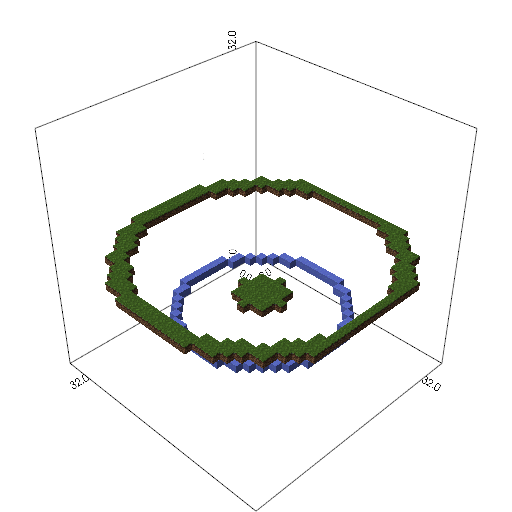

WindowsPath('seed_context_outputs/pond_seed_preview.png')

In [ ]:
# Template cell: start with an empty 32^3 air volume and compose shapes.

voxels, known_mask = new_context(size=32, fill_block="AIR")

# A simple seeded pond/island example.
draw_circle(voxels, known_mask, block="GRASS", axis="y", coord=16, center=(16, 16), radius=16, thickness=2, add_air_above=True)
draw_circle(voxels, known_mask, block="WATER", axis="y", coord=8, center=(16, 16), radius=10, thickness=1, add_air_above=True)
draw_circle(voxels, known_mask, block="GRASS", axis="y", coord=10, center=(16, 16), radius=3, filled=True, add_air_above=True)

preview_context(voxels, known_mask, output_name="pond_seed_preview.png", textured=True, image_size=512)

In [ ]:
save_seed_context(
    OUTPUT_DIR / "pond_seed_context.pt",
    voxels,
    known_mask,
    metadata={
        "notes": "Edit this metadata however you like.",
        "convention": "shape=(H,Y,D), Y is vertical",
    },
)

Saved seed context to seed_context_outputs\pond_seed_context.pt


WindowsPath('seed_context_outputs/pond_seed_context.pt')

Known voxels: 224
Textured preview: True
Fitted camera: False
seed_context_outputs\rings.png


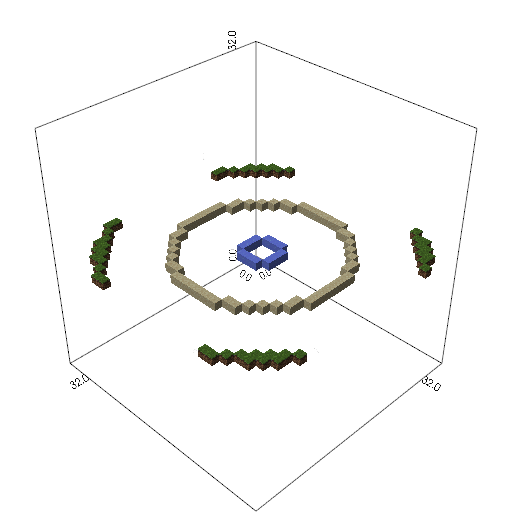

WindowsPath('seed_context_outputs/rings.png')

In [ ]:
voxels, known_mask = new_context(size=32, fill_block="AIR")

draw_circle(voxels, known_mask, block="GRASS", axis="y", coord=16, center=(16, 16), radius=18, thickness=1, add_air_above=True)
draw_circle(voxels, known_mask, block="SAND", axis="y", coord=16, center=(16, 16), radius=10, thickness=1, add_air_above=True)
draw_circle(voxels, known_mask, block="WATER", axis="y", coord=16, center=(16, 16), radius=2, thickness=1, add_air_above=True)


preview_context(voxels, known_mask, output_name="rings.png", textured=True, image_size=512)

In [172]:
save_seed_context(
    OUTPUT_DIR / "rings_context.pt",
    voxels,
    known_mask,
    metadata={
        "notes": "Edit this metadata however you like.",
        "convention": "shape=(H,Y,D), Y is vertical",
    },
)

Saved seed context to seed_context_outputs\rings_context.pt


WindowsPath('seed_context_outputs/rings_context.pt')

c:\Users\TimBits\miniconda3\envs\py39\lib\site-packages\pyvista\core\dataset.py:604: PyVistaDeprecationWarning: Use of `DataSet.active_t_coords` is deprecated. Use `DataSet.active_texture_coordinates` instead.
  warnings.warn(


Known voxels: 64
Textured preview: True
Fitted camera: False
seed_context_outputs\grass_V.png


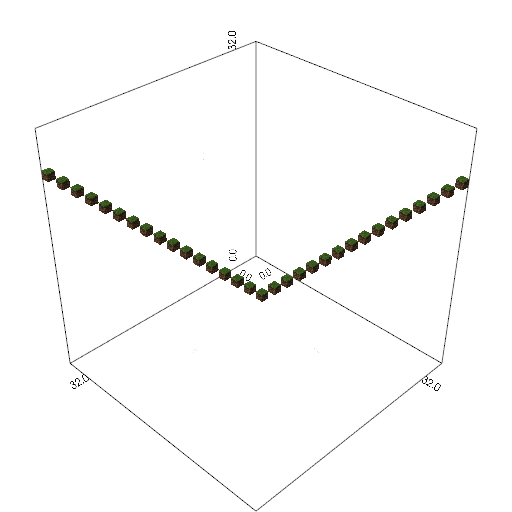

WindowsPath('seed_context_outputs/grass_V.png')

In [ ]:

voxels, known_mask = new_context(size=32, fill_block="AIR")

# A simple seeded pond/island example.
line(voxels, known_mask, block="GRASS", start=(0, 26, 0), end=(16, 10, 16), width=1, add_air_above=True)
line(voxels, known_mask, block="GRASS", start=(16, 10, 16), end=(32, 26, 32), width=1, add_air_above=True)

preview_context(voxels, known_mask, output_name="grass_V.png", textured=True, image_size=512)


In [91]:
save_seed_context(
    OUTPUT_DIR / "grass_v_context.pt",
    voxels,
    known_mask,
    metadata={
        "notes": "grass_v",
        "convention": "shape=(H,Y,D), Y is vertical",
    },
)

Saved seed context to seed_context_outputs\grass_v_context.pt


WindowsPath('seed_context_outputs/grass_v_context.pt')

c:\Users\TimBits\miniconda3\envs\py39\lib\site-packages\pyvista\core\dataset.py:604: PyVistaDeprecationWarning: Use of `DataSet.active_t_coords` is deprecated. Use `DataSet.active_texture_coordinates` instead.
  warnings.warn(


Known voxels: 64
Textured preview: True
Fitted camera: False
seed_context_outputs\sand_grass_V.png


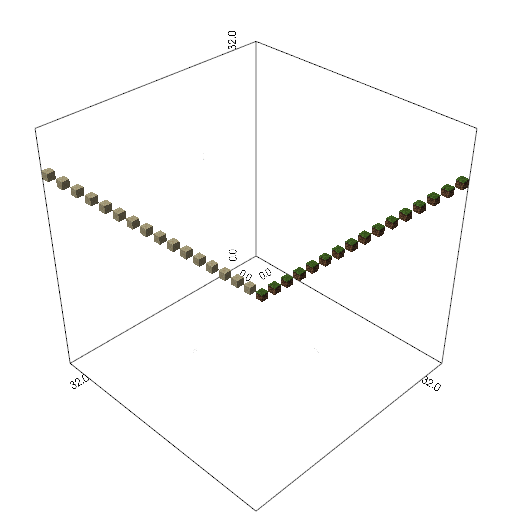

WindowsPath('seed_context_outputs/sand_grass_V.png')

In [ ]:

voxels, known_mask = new_context(size=32, fill_block="AIR")

line(voxels, known_mask, block="SAND", start=(0, 26, 0), end=(16, 10, 16), width=1, add_air_above=True)
line(voxels, known_mask, block="GRASS", start=(16, 10, 16), end=(32, 26, 32), width=1, add_air_above=True)


preview_context(voxels, known_mask, output_name="sand_grass_V.png", textured=True, image_size=512)


In [94]:
save_seed_context(
    OUTPUT_DIR / "sand_grass_v_context.pt",
    voxels,
    known_mask,
    metadata={
        "notes": "grass_v",
        "convention": "shape=(H,Y,D), Y is vertical",
    },
)

Saved seed context to seed_context_outputs\sand_grass_v_context.pt


WindowsPath('seed_context_outputs/sand_grass_v_context.pt')

c:\Users\TimBits\miniconda3\envs\py39\lib\site-packages\pyvista\core\dataset.py:604: PyVistaDeprecationWarning: Use of `DataSet.active_t_coords` is deprecated. Use `DataSet.active_texture_coordinates` instead.
  warnings.warn(


Known voxels: 64
Textured preview: True
Fitted camera: False
seed_context_outputs\sand_grass_V.png


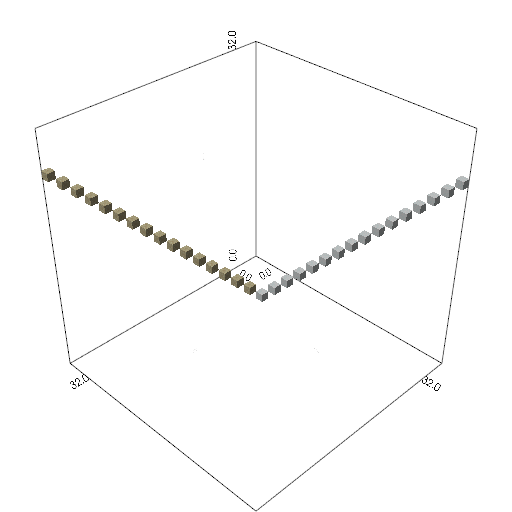

WindowsPath('seed_context_outputs/sand_grass_V.png')

In [ ]:

voxels, known_mask = new_context(size=32, fill_block="AIR")

line(voxels, known_mask, block="SAND", start=(0, 26, 0), end=(16, 10, 16), width=1, add_air_above=True)
line(voxels, known_mask, block="SNOW", start=(16, 10, 16), end=(32, 26, 32), width=1, add_air_above=True)

preview_context(voxels, known_mask, output_name="sand_grass_V.png", textured=True, image_size=512)


In [152]:
save_seed_context(
    OUTPUT_DIR / "sand_snow_v_context.pt",
    voxels,
    known_mask,
    metadata={
        "notes": "grass_v",
        "convention": "shape=(H,Y,D), Y is vertical",
    },
)

Saved seed context to seed_context_outputs\sand_snow_v_context.pt


WindowsPath('seed_context_outputs/sand_snow_v_context.pt')

Known voxels: 120
Textured preview: True
Fitted camera: False
seed_context_outputs\steps.png


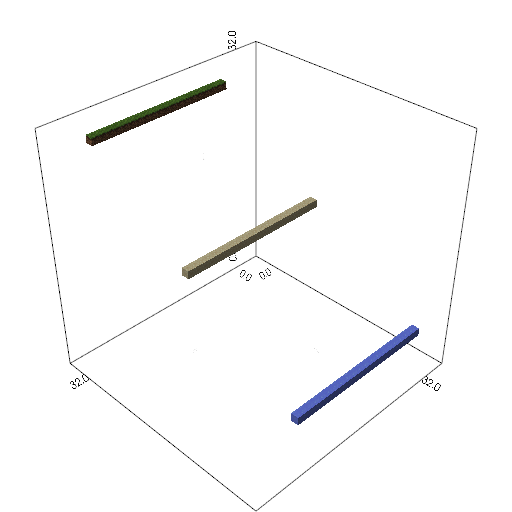

WindowsPath('seed_context_outputs/steps.png')

In [ ]:

voxels, known_mask = new_context(size=32, fill_block="AIR")

draw_plane(voxels, known_mask, block="GRASS", axis="y", coord=28, u_bounds=(6, 26), v_bounds=(0, 1), thickness=1, add_air_above=True)
draw_plane(voxels, known_mask, block="SAND", axis="y", coord=18, u_bounds=(6, 26), v_bounds=(15, 16), thickness=1, add_air_above=True)
draw_plane(voxels, known_mask, block="WATER", axis="y", coord=8, u_bounds=(6, 26), v_bounds=(31, 32), thickness=1, add_air_above=True)

preview_context(voxels, known_mask, output_name="steps.png", textured=True, image_size=512)


In [153]:
save_seed_context(
    OUTPUT_DIR / "steps_context.pt",
    voxels,
    known_mask,
    metadata={
        "notes": "steps",
        "convention": "shape=(H,Y,D), Y is vertical",
    },
)

Saved seed context to seed_context_outputs\steps_context.pt


WindowsPath('seed_context_outputs/steps_context.pt')

Known voxels: 480
Textured preview: True
Fitted camera: False
seed_context_outputs\steps.png


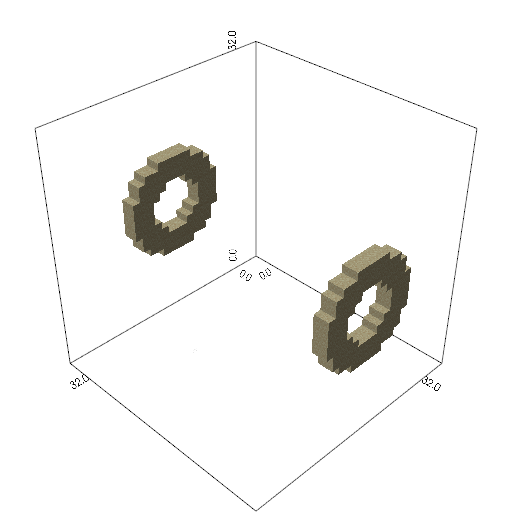

WindowsPath('seed_context_outputs/steps.png')

In [ ]:
voxels, known_mask = new_context(size=32, fill_block="AIR")

draw_circle(voxels, known_mask, block="SAND", axis="z", coord=31, center=(16, 16), radius=5, thickness=3, filled=False, add_air_above=True, air_above_placed_only=True)
draw_circle(voxels, known_mask, block="SAND", axis="z", coord=0, center=(16, 16), radius=5, thickness=3, filled=False, add_air_above=True, air_above_placed_only=True)

preview_context(voxels, known_mask, output_name="steps.png", textured=True, image_size=512)



In [158]:
save_seed_context(
    OUTPUT_DIR / "twodonuts_context.pt",
    voxels,
    known_mask,
    metadata={
        "notes": "steps",
        "convention": "shape=(H,Y,D), Y is vertical",
    },
)

Saved seed context to seed_context_outputs\twodonuts_context.pt


WindowsPath('seed_context_outputs/twodonuts_context.pt')

Known voxels: 1414
Textured preview: True
Fitted camera: False
seed_context_outputs\close_right.png


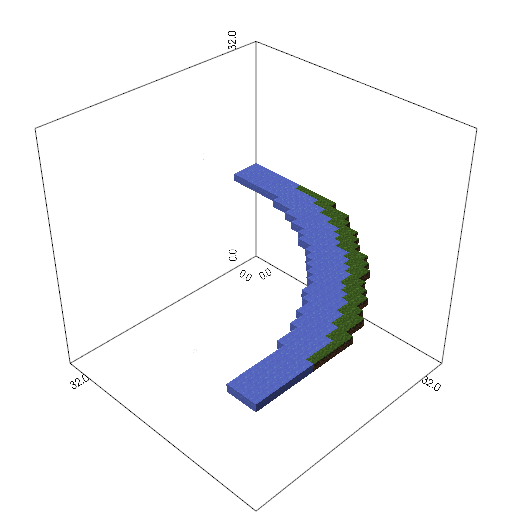

Known voxels: 1440
Textured preview: True
Fitted camera: False
seed_context_outputs\close_left.png


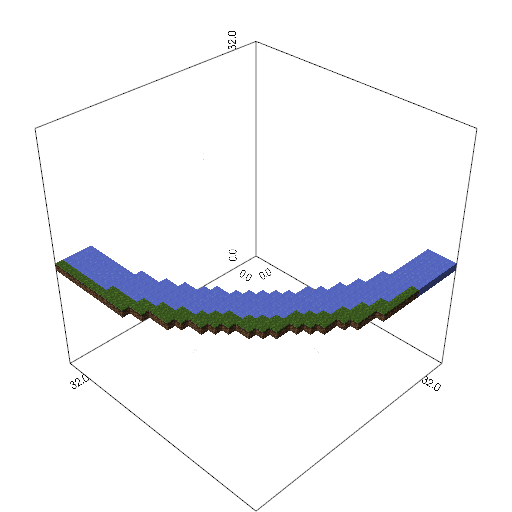

Known voxels: 1440
Textured preview: True
Fitted camera: False
seed_context_outputs\far_right.png


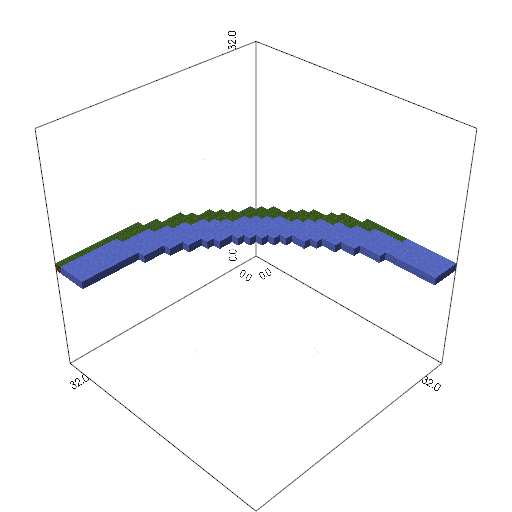

Known voxels: 1454
Textured preview: True
Fitted camera: False
seed_context_outputs\far_left.png


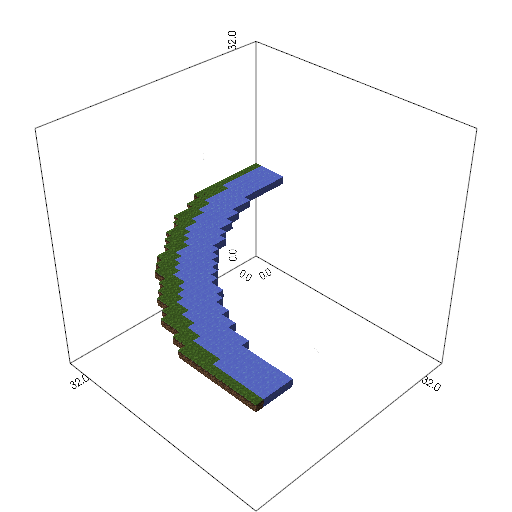

WindowsPath('seed_context_outputs/far_left.png')

In [ ]:

cr_voxels, cr_known_mask = new_context(size=32, fill_block="AIR")
cl_voxels, cl_known_mask = new_context(size=32, fill_block="AIR")
fr_voxels, fr_known_mask = new_context(size=32, fill_block="AIR")
fl_voxels, fl_known_mask = new_context(size=32, fill_block="AIR")

# close right
draw_circle(cr_voxels, cr_known_mask, block="WATER", axis="y", coord=16, center=(0, 0), radius=30, thickness=4, add_air_above=True)
draw_circle(cr_voxels, cr_known_mask, block="GRASS", axis="y", coord=15, center=(0, 0), radius=33, thickness=2, add_air_above=True)

# close left
draw_circle(cl_voxels, cl_known_mask, block="WATER", axis="y", coord=16, center=(32, 0), radius=30, thickness=4, add_air_above=True)
draw_circle(cl_voxels, cl_known_mask, block="GRASS", axis="y", coord=15, center=(32, 0), radius=33, thickness=2, add_air_above=True)

# far right
draw_circle(fr_voxels, fr_known_mask, block="WATER", axis="y", coord=16, center=(0, 32), radius=30, thickness=4, add_air_above=True)
draw_circle(fr_voxels, fr_known_mask, block="GRASS", axis="y", coord=15, center=(0, 32), radius=33, thickness=2, add_air_above=True)

# far left
draw_circle(fl_voxels, fl_known_mask, block="WATER", axis="y", coord=16, center=(32, 32), radius=30, thickness=4, add_air_above=True)
draw_circle(fl_voxels, fl_known_mask, block="GRASS", axis="y", coord=15, center=(32, 32), radius=33, thickness=2, add_air_above=True)


preview_context(cr_voxels, cr_known_mask, output_name="close_right.png", textured=True, image_size=512)
preview_context(cl_voxels, cl_known_mask, output_name="close_left.png", textured=True, image_size=512)
preview_context(fr_voxels, fr_known_mask, output_name="far_right.png", textured=True, image_size=512)
preview_context(fl_voxels, fl_known_mask, output_name="far_left.png", textured=True, image_size=512)

In [63]:
save_seed_context(
    OUTPUT_DIR / "close_right_context.pt",
    cr_voxels,
    cr_known_mask,
    metadata={
        "notes": "Edit this metadata however you like.",
        "convention": "shape=(H,Y,D), Y is vertical",
    },
)
save_seed_context(
    OUTPUT_DIR / "close_left_context.pt",
    cl_voxels,
    cl_known_mask,
    metadata={
        "notes": "Edit this metadata however you like.",
        "convention": "shape=(H,Y,D), Y is vertical",
    },
)
save_seed_context(
    OUTPUT_DIR / "far_right_context.pt",
    fr_voxels,
    fr_known_mask,
    metadata={
        "notes": "Edit this metadata however you like.",
        "convention": "shape=(H,Y,D), Y is vertical",
    },
)
save_seed_context(
    OUTPUT_DIR / "far_left_context.pt",
    fl_voxels,
    fl_known_mask,
    metadata={
        "notes": "Edit this metadata however you like.",
        "convention": "shape=(H,Y,D), Y is vertical",
    },
)

Saved seed context to seed_context_outputs\close_right_context.pt
Saved seed context to seed_context_outputs\close_left_context.pt
Saved seed context to seed_context_outputs\far_right_context.pt
Saved seed context to seed_context_outputs\far_left_context.pt


WindowsPath('seed_context_outputs/far_left_context.pt')

Known voxels: 882
Textured preview: True
Fitted camera: False
seed_context_outputs\tiered_bowl_preview.png


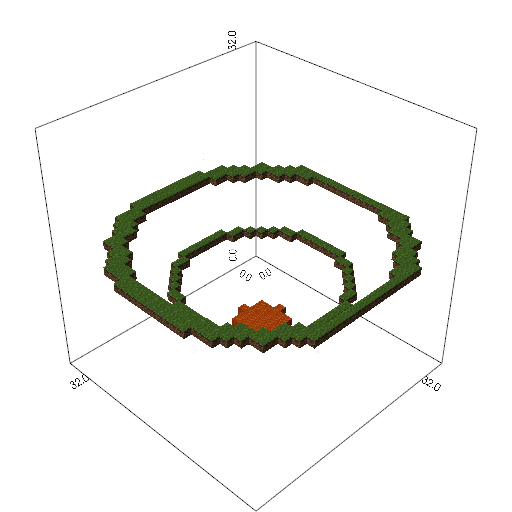

WindowsPath('seed_context_outputs/tiered_bowl_preview.png')

In [ ]:

voxels, known_mask = new_context(size=32, fill_block="AIR")

# A simple seeded pond/island example.
draw_circle(voxels, known_mask, block="GRASS", axis="y", coord=18, center=(16, 16), radius=16, thickness=2, add_air_above=True)
draw_circle(voxels, known_mask, block="GRASS", axis="y", coord=12, center=(16, 16), radius=10, thickness=1, add_air_above=True)
draw_circle(voxels, known_mask, block="LAVA", axis="y", coord=6, center=(16, 16), radius=3, filled=True, add_air_above=True)

preview_context(voxels, known_mask, output_name="tiered_bowl_preview.png", textured=True, image_size=512)

In [65]:
save_seed_context(
    OUTPUT_DIR / "tiered_bowl_lava_context.pt",
    voxels,
    known_mask,
    metadata={
        "notes": "Edit this metadata however you like.",
        "convention": "shape=(H,Y,D), Y is vertical",
    },
)

Saved seed context to seed_context_outputs\tiered_bowl_lava_context.pt


WindowsPath('seed_context_outputs/tiered_bowl_lava_context.pt')

Known voxels: 249
Textured preview: True
Fitted camera: False
seed_context_outputs\lava_mountain_preview.png


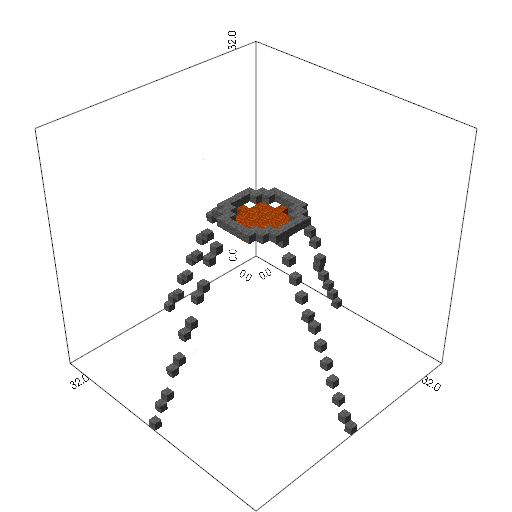

WindowsPath('seed_context_outputs/lava_mountain_preview.png')

In [ ]:

voxels, known_mask = new_context(size=32, fill_block="AIR")

line(voxels, known_mask, block="STONE", start=(15, 0, 0), end=(15, 20, 10), add_air_above=True)
line(voxels, known_mask, block="STONE", start=(31, 0, 15), end=(22, 20, 16), add_air_above=True)
line(voxels, known_mask, block="STONE", start=(0, 0, 15), end=(10, 20, 15), add_air_above=True)
line(voxels, known_mask, block="STONE", start=(15, 0, 31), end=(15, 20, 20), add_air_above=True)
draw_circle(voxels, known_mask, block="STONE", axis="y", coord=21, center=(16, 16), radius=4, thickness=1, add_air_above=True)
draw_circle(voxels, known_mask, block="LAVA", axis="y", coord=20, center=(16, 16), radius=3, filled=True, add_air_above=True)

preview_context(voxels, known_mask, output_name="lava_mountain_preview.png", textured=True, image_size=512)

In [67]:
save_seed_context(
    OUTPUT_DIR / "volcano.pt",
    voxels,
    known_mask,
    metadata={
        "notes": "Edit this metadata however you like.",
        "convention": "shape=(H,Y,D), Y is vertical",
    },
)

Saved seed context to seed_context_outputs\volcano.pt


WindowsPath('seed_context_outputs/volcano.pt')

Known voxels: 1174
Textured preview: True
Fitted camera: False
seed_context_outputs\four_rings_preview.png


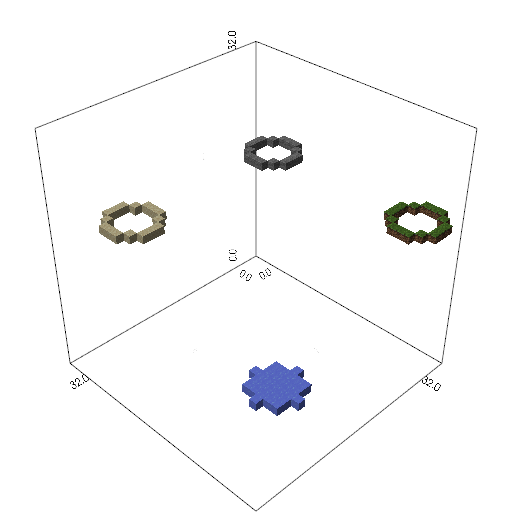

WindowsPath('seed_context_outputs/four_rings_preview.png')

In [ ]:

voxels, known_mask = new_context(size=32, fill_block="AIR")

draw_circle(voxels, known_mask, block="SAND", axis="y", coord=20, center=(6, 6), radius=3, filled=False, add_air_above=True)
draw_circle(voxels, known_mask, block="AIR", axis="y", coord=20, center=(6, 6), radius=2, filled=True, add_air_above=True)
draw_plane(voxels, known_mask, block="AIR", axis="y", coord=24, u_bounds=(3, 10), v_bounds=(3, 10), thickness=6, add_air_above=False)


draw_circle(voxels, known_mask, block="STONE", axis="y", coord=20, center=(28, 6), radius=3, filled=False, add_air_above=True)
draw_circle(voxels, known_mask, block="AIR", axis="y", coord=20, center=(28, 6), radius=2, filled=True, add_air_above=True)
draw_plane(voxels, known_mask, block="AIR", axis="y", coord=24, u_bounds=(25, 32), v_bounds=(3, 10), thickness=6, add_air_above=False)

draw_circle(voxels, known_mask, block="GRASS", axis="y", coord=20, center=(28, 28), radius=3, filled=False, add_air_above=True)
draw_circle(voxels, known_mask, block="AIR", axis="y", coord=20, center=(28, 28), radius=2, filled=True, add_air_above=True)
draw_plane(voxels, known_mask, block="AIR", axis="y", coord=24, u_bounds=(25, 32), v_bounds=(25, 32), thickness=6, add_air_above=False)

draw_circle(voxels, known_mask, block="WATER", axis="y", coord=10, center=(6, 28), radius=3, filled=True, add_air_above=True)


preview_context(voxels, known_mask, output_name="four_rings_preview.png", textured=True, image_size=512)

In [69]:
save_seed_context(
    OUTPUT_DIR / "four_rings.pt",
    voxels,
    known_mask,
    metadata={
        "notes": "Edit this metadata however you like.",
        "convention": "shape=(H,Y,D), Y is vertical",
    },
)

Saved seed context to seed_context_outputs\four_rings.pt


WindowsPath('seed_context_outputs/four_rings.pt')

Known voxels: 130
Textured preview: True
Fitted camera: False
seed_context_outputs\teepee_preview.png


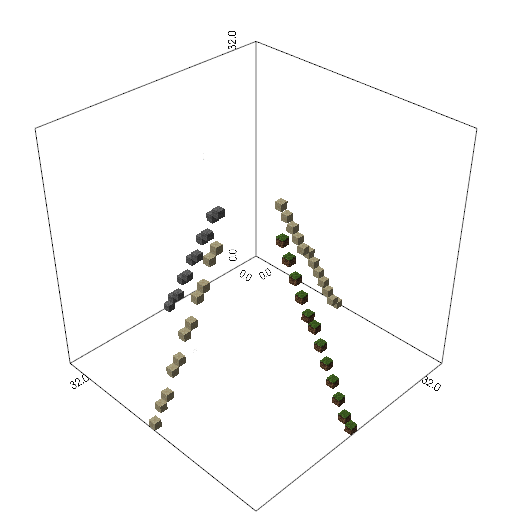

WindowsPath('seed_context_outputs/teepee_preview.png')

In [ ]:

voxels, known_mask = new_context(size=32, fill_block="AIR")

line(voxels, known_mask, block="STONE", start=(15, 0, 0), end=(15, 20, 10), add_air_above=True)
line(voxels, known_mask, block="SAND", start=(31, 0, 15), end=(20, 20, 15), add_air_above=True)
line(voxels, known_mask, block="SAND", start=(0, 0, 15), end=(10, 20, 15), add_air_above=True)
line(voxels, known_mask, block="GRASS", start=(15, 0, 31), end=(15, 20, 20), add_air_above=True)

preview_context(voxels, known_mask, output_name="teepee_preview.png", textured=True, image_size=512)

In [ ]:
save_seed_context(
    OUTPUT_DIR / "teepee.pt",
    voxels,
    known_mask,
    metadata={
        "notes": "Edit this metadata however you like.",
        "convention": "shape=(H,Y,D), Y is vertical",
    },
)

Saved seed context to seed_context_outputs\teepee.pt


WindowsPath('seed_context_outputs/teepee.pt')

Known voxels: 508
Textured preview: True
seed_context_outputs\wave_preview.png


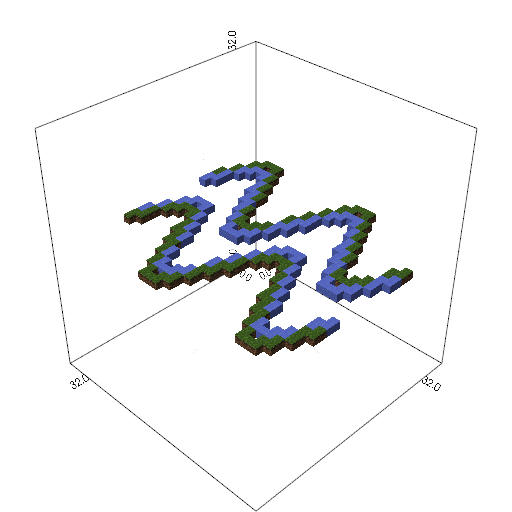

WindowsPath('seed_context_outputs/wave_preview.png')

In [ ]:

voxels, known_mask = new_context(size=32, fill_block="AIR")

wave(voxels, known_mask, block="GRASS", y=16, travel_axis='z', travel_bounds=(0, 31), center=24, amplitude=6.0, wavelength=15.0, add_air_above=True)
wave(voxels, known_mask, block="WATER", y=16, travel_axis='z', travel_bounds=(0, 31), center=22, amplitude=6.0, wavelength=15.0, add_air_above=True)
wave(voxels, known_mask, block="WATER", y=16, travel_axis='z', travel_bounds=(0, 31), center=12, amplitude=6.0, wavelength=15.0, add_air_above=True)
wave(voxels, known_mask, block="GRASS", y=16, travel_axis='z', travel_bounds=(0, 31), center=10, amplitude=6.0, wavelength=15.0, add_air_above=True)


preview_context(voxels, known_mask, output_name="wave_preview.png", textured=True, image_size=512)

In [ ]:
save_seed_context(
    OUTPUT_DIR / "water_wave_grass.pt",
    voxels,
    known_mask,
    metadata={
        "notes": "Edit this metadata however you like.",
        "convention": "shape=(H,Y,D), Y is vertical",
    },
)

Saved seed context to seed_context_outputs\water_wave_grass.pt


WindowsPath('seed_context_outputs/water_wave_grass.pt')

c:\Users\TimBits\miniconda3\envs\py39\lib\site-packages\pyvista\core\dataset.py:604: PyVistaDeprecationWarning: Use of `DataSet.active_t_coords` is deprecated. Use `DataSet.active_texture_coordinates` instead.
  warnings.warn(


Known voxels: 392
Textured preview: True
seed_context_outputs\vertical_wave_preview.png


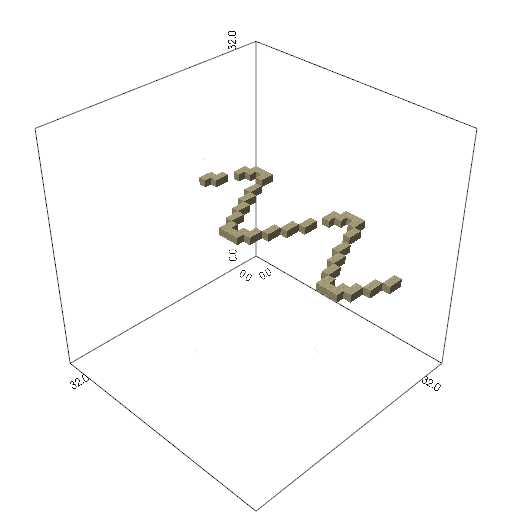

WindowsPath('seed_context_outputs/vertical_wave_preview.png')

In [ ]:

voxels, known_mask = new_context(size=32, fill_block="AIR")


wave(voxels, known_mask, block="AIR", y=16, travel_axis='z', travel_bounds=(0, 31), center=19, amplitude=6.0, wavelength=15.0, add_air_above=True)
wave(voxels, known_mask, block="SAND", y=16, travel_axis='z', travel_bounds=(0, 31), center=22, amplitude=6.0, wavelength=15.0, add_air_above=True)
wave(voxels, known_mask, block="AIR", y=16, travel_axis='z', travel_bounds=(0, 31), center=24, amplitude=6.0, wavelength=15.0, add_air_above=True)


preview_context(voxels, known_mask, output_name="vertical_wave_preview.png", textured=True, image_size=512)

In [ ]:
save_seed_context(
    OUTPUT_DIR / "sand_waves2.pt",
    voxels,
    known_mask,
    metadata={
        "notes": "Edit this metadata however you like.",
        "convention": "shape=(H,Y,D), Y is vertical",
    },
)

Saved seed context to seed_context_outputs\sand_waves2.pt


WindowsPath('seed_context_outputs/sand_waves2.pt')

c:\Users\TimBits\miniconda3\envs\py39\lib\site-packages\pyvista\core\dataset.py:604: PyVistaDeprecationWarning: Use of `DataSet.active_t_coords` is deprecated. Use `DataSet.active_texture_coordinates` instead.
  warnings.warn(


Known voxels: 9024
Textured preview: True
Fitted camera: False
seed_context_outputs\waterfall_preview.png


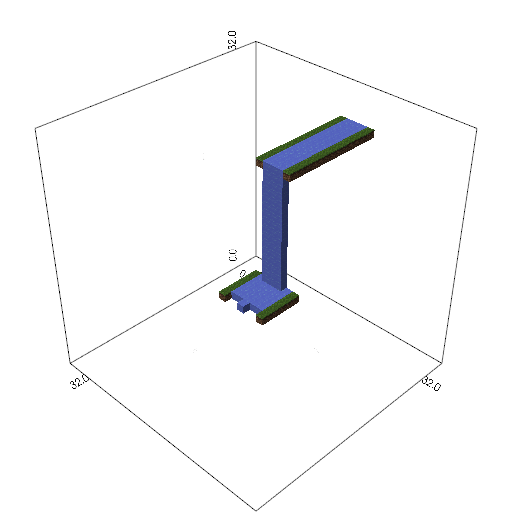

WindowsPath('seed_context_outputs/waterfall_preview.png')

In [ ]:

voxels, known_mask = new_context(size=32, fill_block="AIR")


draw_circle(voxels, known_mask, block="WATER", axis="y", coord=10, center=(16, 16), radius=3, filled=True, add_air_above=True)

draw_plane(voxels, known_mask, block="WATER", axis="y", coord=26, u_bounds=(18, 32), v_bounds=(15, 18), add_air_above=True)
line(voxels, known_mask, block="GRASS", start=(18, 26, 14), end=(31, 26, 14))
line(voxels, known_mask, block="GRASS", start=(18, 26, 18), end=(31, 26, 18))
line(voxels, known_mask, block="WATER", start=(18, 10, 15), end=(18, 26, 15))
line(voxels, known_mask, block="WATER", start=(18, 10, 16), end=(18, 26, 16))
line(voxels, known_mask, block="WATER", start=(18, 10, 17), end=(18, 26, 17))






line(voxels, known_mask, block="GRASS", start=(18, 10, 13), end=(13, 10, 13), add_air_above=True)
line(voxels, known_mask, block="GRASS", start=(18, 10, 19), end=(13, 10, 19), add_air_above=True)
line(voxels, known_mask, block="WATER", start=(18, 10, 17), end=(18, 26, 17), add_air_above=False)

draw_plane(voxels, known_mask, block="AIR", axis="y", coord=24, u_bounds=(0, 16), v_bounds=(0, 32), thickness=16, add_air_above=False)

draw_plane(voxels, known_mask, block="AIR", axis="y", coord=30, u_bounds=(16, 31), v_bounds=(12, 22), thickness=4, add_air_above=False)


preview_context(voxels, known_mask, output_name="waterfall_preview.png", textured=True, image_size=512)

In [ ]:
save_seed_context(
    OUTPUT_DIR / "waterfall_context.pt",
    voxels,
    known_mask,
    metadata={
        "notes": "Edit this metadata however you like.",
        "convention": "shape=(H,Y,D), Y is vertical",
    },
)

Saved seed context to seed_context_outputs\waterfall_context.pt


WindowsPath('seed_context_outputs/waterfall_context.pt')

Known voxels: 1056
Textured preview: True
Fitted camera: False
seed_context_outputs\hole_preview.png


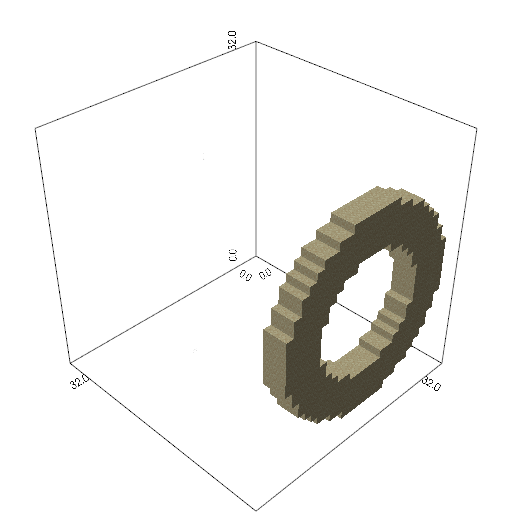

WindowsPath('seed_context_outputs/hole_preview.png')

In [ ]:
fill_idx = resolve_block("AIR")
voxels = torch.full((32, 32, 32), fill_idx, dtype=torch.long)
known_mask = torch.zeros((32, 32, 32), dtype=torch.bool)


draw_circle(voxels, known_mask, block="SAND", axis="z", coord=31, center=(16, 16), radius=10, thickness=5, filled=False, add_air_above=True, air_above_placed_only=True)

preview_context(voxels, known_mask, output_name="hole_preview.png", textured=True, image_size=512, show_axis=True)

In [206]:
save_seed_context(
    OUTPUT_DIR / "sand_donut_close.pt",
    voxels,
    known_mask,
    metadata={
        "notes": "Edit this metadata however you like.",
        "convention": "shape=(H,Y,D), Y is vertical",
    },
)

Saved seed context to seed_context_outputs\sand_donut_close.pt


WindowsPath('seed_context_outputs/sand_donut_close.pt')

## Village stuff

Loaded piece: (5, 7, 1), meta: {'source_file': 'renders\\user_study_samples\\real_samples\\generated_village.pt', 'source_sample_idx': 17, 'source_slice_h': (12, 17), 'source_slice_y': (16, 23), 'source_slice_d': (26, 27)}
Pasted 35 voxels at origin (2, 10, 6) with rotate_y_turns=0 | piece_known_mask=assumed_all
Pasted 35 voxels at origin (10, 10, 6) with rotate_y_turns=0 | piece_known_mask=assumed_all
Pasted 35 voxels at origin (18, 10, 6) with rotate_y_turns=0 | piece_known_mask=assumed_all
Pasted 35 voxels at origin (24, 10, 8) with rotate_y_turns=1 | piece_known_mask=assumed_all
Pasted 35 voxels at origin (24, 10, 16) with rotate_y_turns=1 | piece_known_mask=assumed_all
Pasted 35 voxels at origin (24, 10, 24) with rotate_y_turns=1 | piece_known_mask=assumed_all


c:\Users\TimBits\miniconda3\envs\py39\lib\site-packages\pyvista\core\dataset.py:604: PyVistaDeprecationWarning: Use of `DataSet.active_t_coords` is deprecated. Use `DataSet.active_texture_coordinates` instead.
  warnings.warn(


Known voxels: 338
Textured preview: True
Fitted camera: False
seed_context_outputs\village_piece_pasted.png


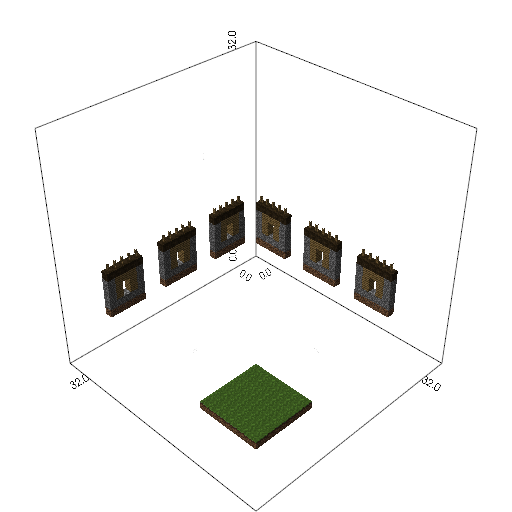

WindowsPath('seed_context_outputs/village_piece_pasted.png')

In [207]:
# ── Step 3: Paste a Piece into a New Context ─────────────────────────────
# Load a saved piece and paste it into a fresh (or existing) context volume.

piece_voxels, piece_meta = load_piece(OUTPUT_DIR / f"hut_front_01.pt")
print(f"Loaded piece: {tuple(piece_voxels.shape)}, meta: {piece_meta}")

voxels, known = new_context(size=32, fill_block="AIR")

# PASTE_ORIGIN = (2, 10, 6)  # ← (h, y, d) where the piece's corner lands
paste_piece(voxels, known, piece_voxels, origin=(2, 10, 6), skip_air=False)
paste_piece(voxels, known, piece_voxels, origin=(10, 10, 6), skip_air=False)
paste_piece(voxels, known, piece_voxels, origin=(18, 10, 6), skip_air=False)
paste_piece(voxels, known, piece_voxels, origin=(24, 10, 8), skip_air=False, rotate_y_turns=1)
paste_piece(voxels, known, piece_voxels, origin=(24, 10, 16), skip_air=False, rotate_y_turns=1)
paste_piece(voxels, known, piece_voxels, origin=(24, 10, 24), skip_air=False, rotate_y_turns=1)

draw_plane(voxels, known, block="GRASS", axis="y", coord=9, u_bounds=(0, 8), v_bounds=(24, 32), thickness=1, add_air_above=True)



preview_context(voxels, known, output_name="village_piece_pasted.png", textured=True, image_size=512)

In [208]:
save_seed_context(
    OUTPUT_DIR / "L_houses.pt",
    voxels,
    known,
    metadata={
        "notes": "Edit this metadata however you like.",
        "convention": "shape=(H,Y,D), Y is vertical",
    },
)

Saved seed context to seed_context_outputs\L_houses.pt


WindowsPath('seed_context_outputs/L_houses.pt')

Loaded: seed_context_outputs\L_houses.pt
Shape: (32, 32, 32)
Context voxels: 338
Inpaint voxels: 32430
Metadata: {'notes': 'Edit this metadata however you like.', 'convention': 'shape=(H,Y,D), Y is vertical'}
Known voxels: 338
Textured preview: True
Fitted camera: False
seed_context_outputs\L_houses_loaded_like_inpaint.png


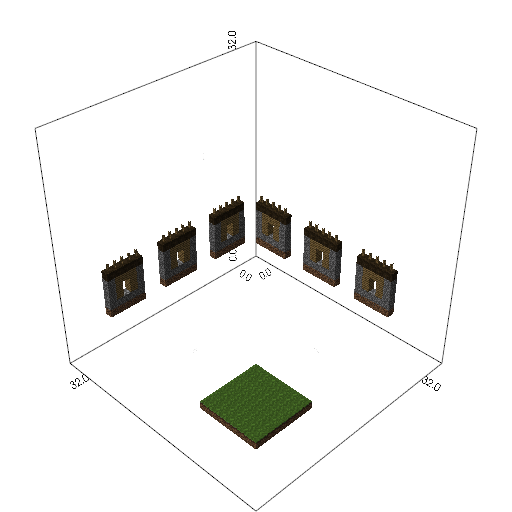

WindowsPath('seed_context_outputs/L_houses_loaded_like_inpaint.png')

In [209]:
context_path = OUTPUT_DIR / "L_houses.pt"
source_indices, context_mask, metadata = load_seed_context(context_path)
inpaint_mask = ~context_mask

print(f"Loaded: {context_path}")
print(f"Shape: {tuple(source_indices.shape)}")
print(f"Context voxels: {int(context_mask.sum().item())}")
print(f"Inpaint voxels: {int(inpaint_mask.sum().item())}")
print(f"Metadata: {metadata}")

preview_context(
    source_indices,
    context_mask,
    output_name=f"{Path(context_path).stem}_loaded_like_inpaint.png",
    textured=True,
    image_size=512,
    show_axis=True,
)

Loaded piece: (5, 15, 1), meta: {'source_file': 'renders\\user_study_samples\\real_samples\\generated_village.pt', 'source_sample_idx': 17, 'source_slice_h': (2, 7), 'source_slice_y': (11, 26), 'source_slice_d': (8, 9)}
Pasted 75 voxels at origin (6, 10, 12) with rotate_y_turns=0 | piece_known_mask=assumed_all
Pasted 75 voxels at origin (16, 10, 26) with rotate_y_turns=1 | piece_known_mask=assumed_all
Known voxels: 192
Textured preview: True
Fitted camera: False
seed_context_outputs\village_piece_pasted.png


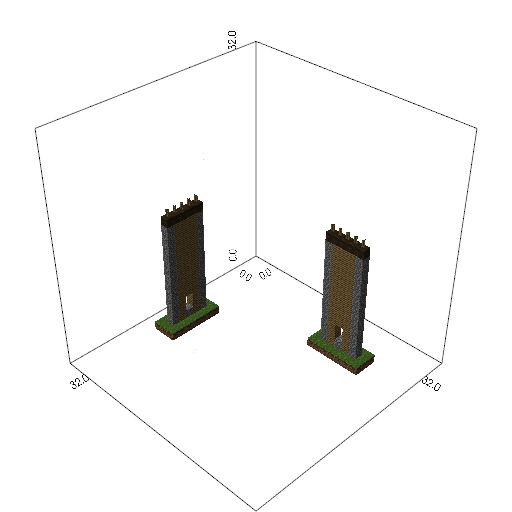

WindowsPath('seed_context_outputs/village_piece_pasted.png')

In [ ]:


piece_voxels, piece_meta = load_piece(OUTPUT_DIR / f"tower_front_01.pt")
print(f"Loaded piece: {tuple(piece_voxels.shape)}, meta: {piece_meta}")

voxels, known = new_context(size=32, fill_block="AIR")

paste_piece(voxels, known, piece_voxels, origin=(6, 10, 12), skip_air=False)
paste_piece(voxels, known, piece_voxels, origin=(16, 10, 26), skip_air=False, rotate_y_turns=1)
draw_plane(voxels, known, block="GRASS", axis="y", coord=9, u_bounds=(5, 12), v_bounds=(11, 14), thickness=1, add_air_above=False)
draw_plane(voxels, known, block="GRASS", axis="y", coord=9, u_bounds=(15, 18), v_bounds=(25, 32), thickness=1, add_air_above=False)



preview_context(voxels, known, output_name="village_piece_pasted.png", textured=True, image_size=512)

In [211]:
save_seed_context(
    OUTPUT_DIR / "towers.pt",
    voxels,
    known,
    metadata={
        "notes": "Edit this metadata however you like.",
        "convention": "shape=(H,Y,D), Y is vertical",
    },
)

Saved seed context to seed_context_outputs\towers.pt


WindowsPath('seed_context_outputs/towers.pt')

In [111]:
torch.unique(voxels, return_counts=True)

(tensor([ 2, 20, 27, 34, 56, 65]),
 tensor([32479,    11,     5,     5,   261,     7]))

# World-level templates

## Four biomes river

Known voxels: 2922
Textured preview: True
Fitted camera: True
seed_context_outputs\big4context.png


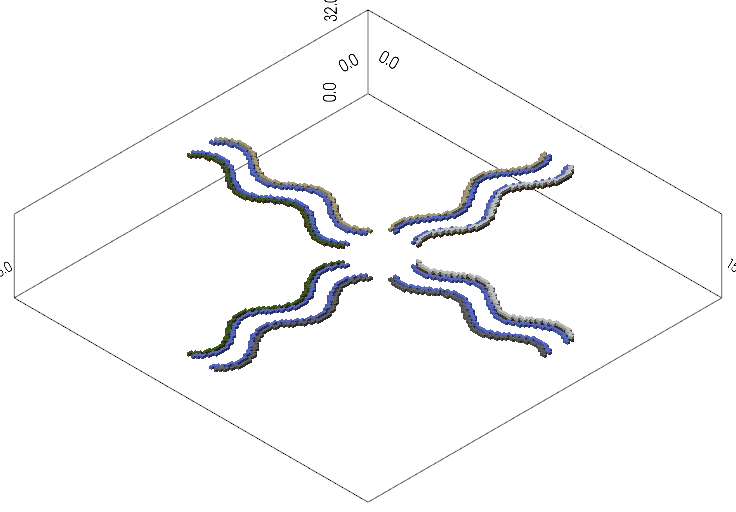

WindowsPath('seed_context_outputs/big4context.png')

In [ ]:
grid_size = (5, 5)
voxels, known_mask = new_context_grid(grid_size, cell_size=32, overlap=1, height=32, fill_block="AIR")


wave(voxels, known_mask, block="SAND", y=16, travel_axis='x', travel_bounds=(92, 159), center=76, amplitude=4.0, wavelength=35.0, add_air_above=True)
wave(voxels, known_mask, block="WATER", y=16, travel_axis='x', travel_bounds=(92, 159), center=78, amplitude=4.0, wavelength=35.0, add_air_above=True)
wave(voxels, known_mask, block="WATER", y=16, travel_axis='x', travel_bounds=(92, 159), center=86, amplitude=4.0, wavelength=35.0, add_air_above=True)
wave(voxels, known_mask, block="GRASS", y=16, travel_axis='x', travel_bounds=(92, 159), center=88, amplitude=4.0, wavelength=35.0, add_air_above=True)
wave(voxels, known_mask, block="SNOW", y=17, travel_axis='x', travel_bounds=(92, 159), center=88, amplitude=4.0, wavelength=35.0, add_air_above=True)


wave(voxels, known_mask, block="GRASS", y=16, travel_axis='x', travel_bounds=(0, 70), center=76, amplitude=4.0, wavelength=35.0, add_air_above=True)
wave(voxels, known_mask, block="WATER", y=16, travel_axis='x', travel_bounds=(0, 70), center=78, amplitude=4.0, wavelength=35.0, add_air_above=True)
wave(voxels, known_mask, block="WATER", y=16, travel_axis='x', travel_bounds=(0, 70), center=86, amplitude=4.0, wavelength=35.0, add_air_above=True)
wave(voxels, known_mask, block="STONE", y=16, travel_axis='x', travel_bounds=(0, 70), center=88, amplitude=4.0, wavelength=35.0, add_air_above=True)

wave(voxels, known_mask, block="GRASS", y=16, travel_axis='z', travel_bounds=(0, 70), center=76, amplitude=4.0, wavelength=35.0, add_air_above=True)
wave(voxels, known_mask, block="WATER", y=16, travel_axis='z', travel_bounds=(0, 70), center=78, amplitude=4.0, wavelength=35.0, add_air_above=True)
wave(voxels, known_mask, block="WATER", y=16, travel_axis='z', travel_bounds=(0, 70), center=86, amplitude=4.0, wavelength=35.0, add_air_above=True)
wave(voxels, known_mask, block="SAND", y=16, travel_axis='z', travel_bounds=(0, 70), center=88, amplitude=4.0, wavelength=35.0, add_air_above=True)

wave(voxels, known_mask, block="STONE", y=16, travel_axis='z', travel_bounds=(92, 159), center=76, amplitude=4.0, wavelength=35.0, add_air_above=True)
wave(voxels, known_mask, block="WATER", y=16, travel_axis='z', travel_bounds=(92, 159), center=78, amplitude=4.0, wavelength=35.0, add_air_above=True)

wave(voxels, known_mask, block="WATER", y=16, travel_axis='z', travel_bounds=(92, 159), center=86, amplitude=4.0, wavelength=35.0, add_air_above=True)
wave(voxels, known_mask, block="GRASS", y=16, travel_axis='z', travel_bounds=(92, 159), center=88, amplitude=4.0, wavelength=35.0, add_air_above=True)
wave(voxels, known_mask, block="SNOW", y=17, travel_axis='z', travel_bounds=(92, 159), center=88, amplitude=4.0, wavelength=35.0, add_air_above=True)



preview_context(voxels, known_mask, output_name="big4context.png", textured=True, image_size=512, show_axis=True)

In [35]:
export_info = export_context_grid_layout(
    voxels,
    known_mask,
    layout_prefix="biomes_river_ol1",
    overlap=1,
    render_previews=False,
)

Saved seed context to seed_context_outputs\biomes_river_ol1_h00_d00.pt
Saved seed context to seed_context_outputs\biomes_river_ol1_h00_d01.pt
Saved seed context to seed_context_outputs\biomes_river_ol1_h00_d02.pt
Saved seed context to seed_context_outputs\biomes_river_ol1_h00_d03.pt
Saved seed context to seed_context_outputs\biomes_river_ol1_h00_d04.pt
Saved seed context to seed_context_outputs\biomes_river_ol1_h01_d00.pt
Saved seed context to seed_context_outputs\biomes_river_ol1_h01_d01.pt
Saved seed context to seed_context_outputs\biomes_river_ol1_h01_d02.pt
Saved seed context to seed_context_outputs\biomes_river_ol1_h01_d03.pt
Saved seed context to seed_context_outputs\biomes_river_ol1_h01_d04.pt
Saved seed context to seed_context_outputs\biomes_river_ol1_h02_d00.pt
Saved seed context to seed_context_outputs\biomes_river_ol1_h02_d01.pt
Saved seed context to seed_context_outputs\biomes_river_ol1_h02_d02.pt
Saved seed context to seed_context_outputs\biomes_river_ol1_h02_d03.pt
Saved 

## Water Spiral

Known voxels: 18289
Textured preview: True
Fitted camera: True
seed_context_outputs\bigcircle.png


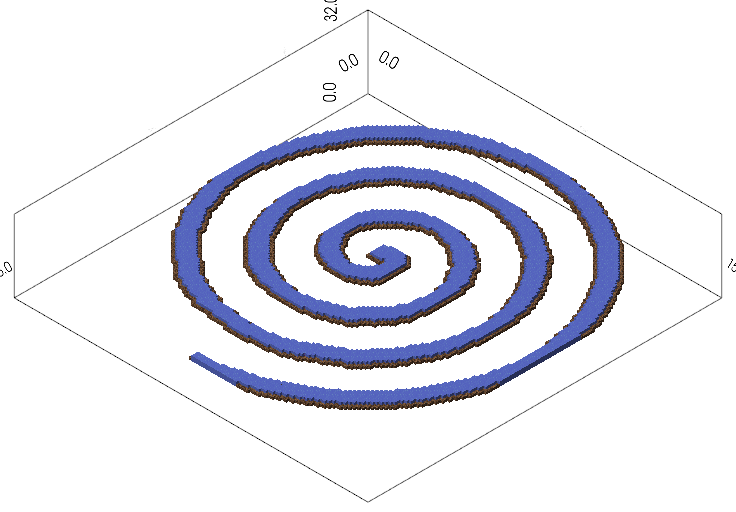

WindowsPath('seed_context_outputs/bigcircle.png')

In [ ]:
grid_size = (5, 5)
voxels, known_mask = new_context_grid(grid_size, cell_size=32, overlap=1, height=32, fill_block="AIR")


draw_spiral(voxels, known_mask, block="DIRT", axis="y", coord=15, center=(80, 80), start_radius=1.0, end_radius=80.0, turns=3.5, samples=300, width=6, add_air_above=False)
draw_spiral(voxels, known_mask, block="WATER", axis="y", coord=15, center=(80, 80), start_radius=1.0, end_radius=80.0, turns=3.5, samples=300, width=4, add_air_above=False)

draw_spiral(voxels, known_mask, block="WATER", axis="y", coord=16, center=(80, 80), start_radius=1.0, end_radius=80.0, turns=3.5, samples=300, width=4, add_air_above=True)


preview_context(voxels, known_mask, output_name="bigcircle.png", textured=True, image_size=512, show_axis=True)

In [37]:
export_info = export_context_grid_layout(
    voxels,
    known_mask,
    layout_prefix="water_spiral_ol1",
    overlap=1,
    render_previews=False,
)

Saved seed context to seed_context_outputs\water_spiral_ol1_h00_d00.pt
Saved seed context to seed_context_outputs\water_spiral_ol1_h00_d01.pt
Saved seed context to seed_context_outputs\water_spiral_ol1_h00_d02.pt
Saved seed context to seed_context_outputs\water_spiral_ol1_h00_d03.pt
Saved seed context to seed_context_outputs\water_spiral_ol1_h00_d04.pt
Saved seed context to seed_context_outputs\water_spiral_ol1_h01_d00.pt
Saved seed context to seed_context_outputs\water_spiral_ol1_h01_d01.pt
Saved seed context to seed_context_outputs\water_spiral_ol1_h01_d02.pt
Saved seed context to seed_context_outputs\water_spiral_ol1_h01_d03.pt
Saved seed context to seed_context_outputs\water_spiral_ol1_h01_d04.pt
Saved seed context to seed_context_outputs\water_spiral_ol1_h02_d00.pt
Saved seed context to seed_context_outputs\water_spiral_ol1_h02_d01.pt
Saved seed context to seed_context_outputs\water_spiral_ol1_h02_d02.pt
Saved seed context to seed_context_outputs\water_spiral_ol1_h02_d03.pt
Saved 

## Grass Spiral

c:\Users\TimBits\miniconda3\envs\py39\lib\site-packages\pyvista\core\dataset.py:604: PyVistaDeprecationWarning: Use of `DataSet.active_t_coords` is deprecated. Use `DataSet.active_texture_coordinates` instead.
  warnings.warn(


Known voxels: 13362
Textured preview: True
Fitted camera: True
seed_context_outputs\biggrasspiral2.png


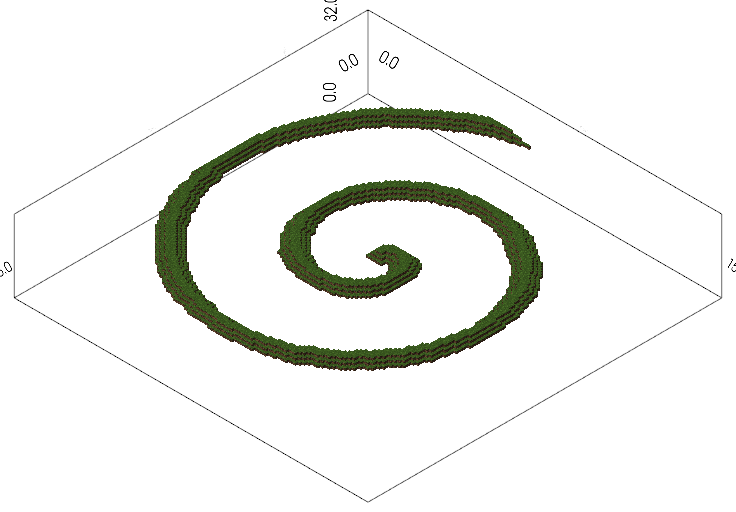

WindowsPath('seed_context_outputs/biggrasspiral2.png')

In [ ]:
grid_size = (5, 5)
voxels, known_mask = new_context_grid(grid_size, cell_size=32, overlap=1, height=32, fill_block="AIR")

draw_spiral(voxels, known_mask, block="GRASS", axis="y", coord=15, center=(80, 80), start_radius=1.0, end_radius=80.0, turns=2, samples=300, width=6, add_air_above=True)
draw_spiral(voxels, known_mask, block="DIRT", axis="y", coord=15, center=(80, 80), start_radius=1.0, end_radius=80.0, turns=2, samples=300, width=4, add_air_above=False)

draw_spiral(voxels, known_mask, block="GRASS", axis="y", coord=16, center=(80, 80), start_radius=1.0, end_radius=80.0, turns=2, samples=300, width=4, add_air_above=True)

draw_spiral(voxels, known_mask, block="GRASS", axis="y", coord=17, center=(80, 80), start_radius=1.0, end_radius=80.0, turns=2, samples=300, width=2, add_air_above=True)


preview_context(voxels, known_mask, output_name="biggrasspiral2.png", textured=True, image_size=512, show_axis=True)

In [39]:
export_info = export_context_grid_layout(
    voxels,
    known_mask,
    layout_prefix="grass_spiral_ol1",
    overlap=1,
    render_previews=False,
)

Saved seed context to seed_context_outputs\grass_spiral_ol1_h00_d00.pt
Saved seed context to seed_context_outputs\grass_spiral_ol1_h00_d01.pt
Saved seed context to seed_context_outputs\grass_spiral_ol1_h00_d02.pt
Saved seed context to seed_context_outputs\grass_spiral_ol1_h00_d03.pt
Saved seed context to seed_context_outputs\grass_spiral_ol1_h00_d04.pt
Saved seed context to seed_context_outputs\grass_spiral_ol1_h01_d00.pt
Saved seed context to seed_context_outputs\grass_spiral_ol1_h01_d01.pt
Saved seed context to seed_context_outputs\grass_spiral_ol1_h01_d02.pt
Saved seed context to seed_context_outputs\grass_spiral_ol1_h01_d03.pt
Saved seed context to seed_context_outputs\grass_spiral_ol1_h01_d04.pt
Saved seed context to seed_context_outputs\grass_spiral_ol1_h02_d00.pt
Saved seed context to seed_context_outputs\grass_spiral_ol1_h02_d01.pt
Saved seed context to seed_context_outputs\grass_spiral_ol1_h02_d02.pt
Saved seed context to seed_context_outputs\grass_spiral_ol1_h02_d03.pt
Saved 

## Water Spokes

Known voxels: 1716
Textured preview: True
Fitted camera: True
seed_context_outputs\spokes.png


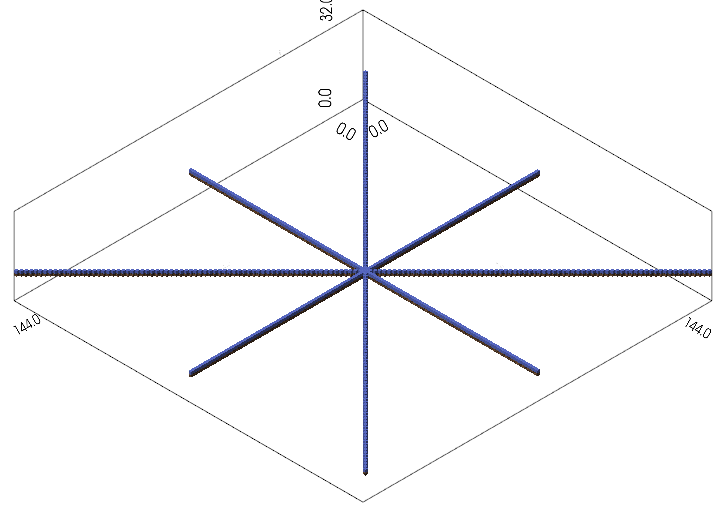

WindowsPath('seed_context_outputs/spokes.png')

In [ ]:
grid_size = (5, 5)
voxels, known_mask = new_context_grid(grid_size, cell_size=32, overlap=4, height=32, fill_block="AIR")


draw_line(voxels, known_mask, block="WATER", start=(0, 10, 0), end=(144, 10, 144), width=1, add_air_above=True)
draw_line(voxels, known_mask, block="DIRT", start=(0, 9, 0), end=(144, 9, 144), width=1, add_air_above=False)


draw_line(voxels, known_mask, block="WATER", start=(144, 10, 0), end=(0, 10, 144), width=1, add_air_above=True)
draw_line(voxels, known_mask, block="DIRT", start=(144, 9, 0), end=(0, 9, 144), width=1, add_air_above=False)

draw_line(voxels, known_mask, block="WATER", start=(72, 10, 0), end=(72, 10, 144), width=1, add_air_above=True)
draw_line(voxels, known_mask, block="DIRT", start=(72, 9, 0), end=(72, 9, 144), width=1, add_air_above=False)

draw_line(voxels, known_mask, block="WATER", start=(0, 10, 72), end=(144, 10, 72), width=1, add_air_above=True)
draw_line(voxels, known_mask, block="DIRT", start=(0, 9, 72), end=(144, 9, 72), width=1, add_air_above=False)





preview_context(voxels, known_mask, output_name="spokes.png", textured=True, image_size=512, show_axis=True)

In [52]:
export_info = export_context_grid_layout(
    voxels,
    known_mask,
    layout_prefix="spokes_dirt",
    overlap=4,
    render_previews=False,
)

Saved seed context to seed_context_outputs\spokes_dirt_h00_d00.pt
Saved seed context to seed_context_outputs\spokes_dirt_h00_d01.pt
Saved seed context to seed_context_outputs\spokes_dirt_h00_d02.pt
Saved seed context to seed_context_outputs\spokes_dirt_h00_d03.pt
Saved seed context to seed_context_outputs\spokes_dirt_h00_d04.pt
Saved seed context to seed_context_outputs\spokes_dirt_h01_d00.pt
Saved seed context to seed_context_outputs\spokes_dirt_h01_d01.pt
Saved seed context to seed_context_outputs\spokes_dirt_h01_d02.pt
Saved seed context to seed_context_outputs\spokes_dirt_h01_d03.pt
Saved seed context to seed_context_outputs\spokes_dirt_h01_d04.pt
Saved seed context to seed_context_outputs\spokes_dirt_h02_d00.pt
Saved seed context to seed_context_outputs\spokes_dirt_h02_d01.pt
Saved seed context to seed_context_outputs\spokes_dirt_h02_d02.pt
Saved seed context to seed_context_outputs\spokes_dirt_h02_d03.pt
Saved seed context to seed_context_outputs\spokes_dirt_h02_d04.pt
Saved seed

c:\Users\TimBits\miniconda3\envs\py39\lib\site-packages\pyvista\core\dataset.py:604: PyVistaDeprecationWarning: Use of `DataSet.active_t_coords` is deprecated. Use `DataSet.active_texture_coordinates` instead.
  warnings.warn(


Known voxels: 3950
Textured preview: True
Fitted camera: True
seed_context_outputs\dreamcubed_stitched_notebook_check.png


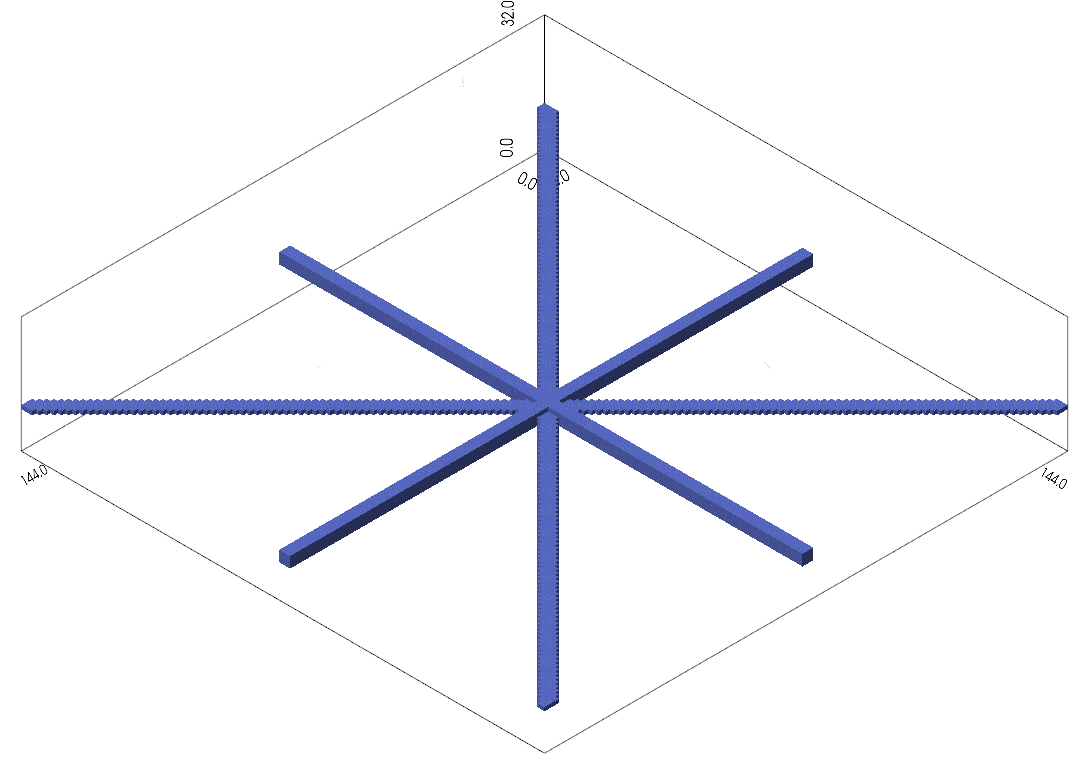

Stitched world shape: (144, 32, 144)
Seeded placements: 25
Seeded voxels: 4666


In [14]:
stitched_voxels, stitched_known_mask, meta = preview_stitched_seed_context(
    OUTPUT_DIR / "spokes.json",
    output_name="dreamcubed_stitched_notebook_check.png",
    cell_size=32,
    overlap=4,
    vertical_overlap=4,
    textured=True,
    image_size=768,
    show_axis=True,
)

## One Spiral

c:\Users\TimBits\miniconda3\envs\py39\lib\site-packages\pyvista\core\dataset.py:604: PyVistaDeprecationWarning: Use of `DataSet.active_t_coords` is deprecated. Use `DataSet.active_texture_coordinates` instead.
  warnings.warn(


Known voxels: 4156
Textured preview: True
Fitted camera: True
seed_context_outputs\onespiral.png


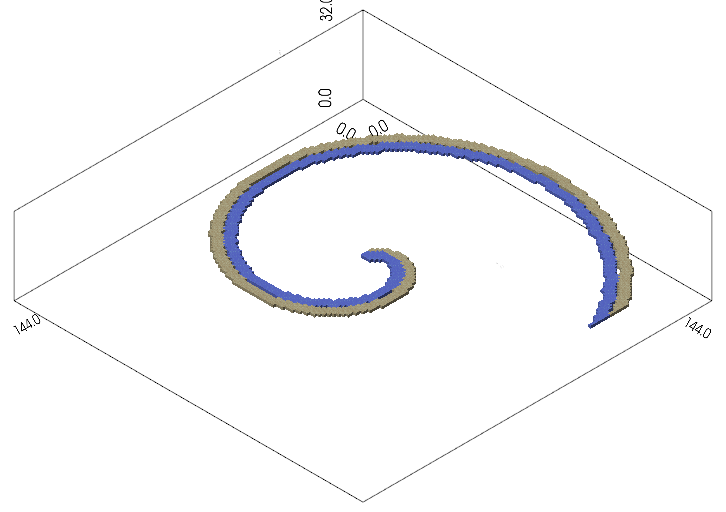

WindowsPath('seed_context_outputs/onespiral.png')

In [ ]:
grid_size = (5, 5)
voxels, known_mask = new_context_grid(grid_size, cell_size=32, overlap=4, height=32, fill_block="AIR")



draw_spiral(voxels, known_mask, block="SAND", axis="y", coord=15, center=(72, 72), start_radius=1.0, end_radius=80.0, turns=1.2, samples=300, width=3, add_air_above=True)
draw_spiral(voxels, known_mask, block="WATER", axis="y", coord=15, center=(72, 72), start_radius=1.0, end_radius=80.0, turns=1.2, samples=300, width=3, angle_offset=math.pi/8, add_air_above=True)


preview_context(voxels, known_mask, output_name="onespiral.png", textured=True, image_size=512, show_axis=True)

In [164]:
export_info = export_context_grid_layout(
    voxels,
    known_mask,
    layout_prefix="onespiral_sand",
    overlap=4,
    render_previews=False,
)

Saved seed context to seed_context_outputs\onespiral_sand_h00_d00.pt
Saved seed context to seed_context_outputs\onespiral_sand_h00_d01.pt
Saved seed context to seed_context_outputs\onespiral_sand_h00_d02.pt
Saved seed context to seed_context_outputs\onespiral_sand_h00_d03.pt
Saved seed context to seed_context_outputs\onespiral_sand_h00_d04.pt
Saved seed context to seed_context_outputs\onespiral_sand_h01_d00.pt
Saved seed context to seed_context_outputs\onespiral_sand_h01_d01.pt
Saved seed context to seed_context_outputs\onespiral_sand_h01_d02.pt
Saved seed context to seed_context_outputs\onespiral_sand_h01_d03.pt
Saved seed context to seed_context_outputs\onespiral_sand_h01_d04.pt
Saved seed context to seed_context_outputs\onespiral_sand_h02_d00.pt
Saved seed context to seed_context_outputs\onespiral_sand_h02_d01.pt
Saved seed context to seed_context_outputs\onespiral_sand_h02_d02.pt
Saved seed context to seed_context_outputs\onespiral_sand_h02_d03.pt
Saved seed context to seed_context

## Raised Spiral

c:\Users\TimBits\miniconda3\envs\py39\lib\site-packages\pyvista\core\dataset.py:604: PyVistaDeprecationWarning: Use of `DataSet.active_t_coords` is deprecated. Use `DataSet.active_texture_coordinates` instead.
  warnings.warn(


Known voxels: 7072
Textured preview: True
Fitted camera: True
seed_context_outputs\raised.png


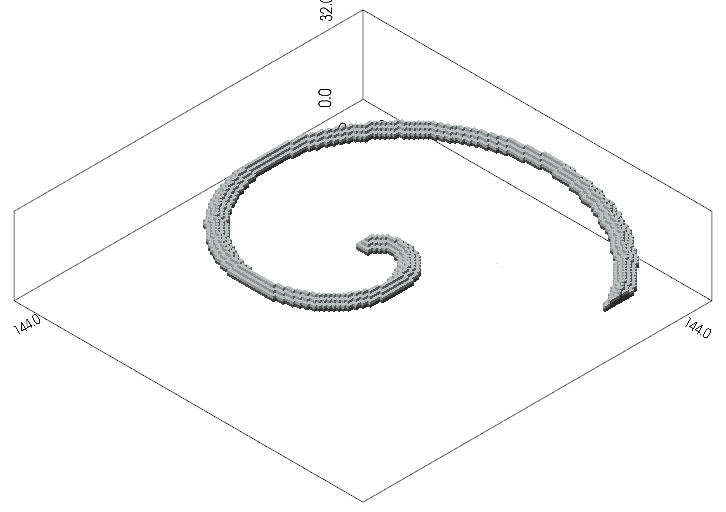

WindowsPath('seed_context_outputs/raised.png')

In [ ]:
grid_size = (5, 5)
voxels, known_mask = new_context_grid(grid_size, cell_size=32, overlap=4, height=32, fill_block="AIR")



draw_spiral(voxels, known_mask, block="STONE", axis="y", coord=18, center=(72, 72), start_radius=1.0, end_radius=80.0, turns=1.2, samples=300, width=4, add_air_above=True)
draw_spiral(voxels, known_mask, block="SNOW", axis="y", coord=19, center=(72, 72), start_radius=1.0, end_radius=80.0, turns=1.2, samples=300, width=4, add_air_above=True)
draw_spiral(voxels, known_mask, block="STONE", axis="y", coord=19, center=(72, 72), start_radius=1.0, end_radius=80.0, turns=1.2, samples=300, width=2, add_air_above=True)
draw_spiral(voxels, known_mask, block="SNOW", axis="y", coord=20, center=(72, 72), start_radius=1.0, end_radius=80.0, turns=1.2, samples=300, width=2, add_air_above=True)
draw_spiral(voxels, known_mask, block="STONE", axis="y", coord=20, center=(72, 72), start_radius=1.0, end_radius=80.0, turns=1.2, samples=300, width=1, add_air_above=True)
draw_spiral(voxels, known_mask, block="SNOW", axis="y", coord=21, center=(72, 72), start_radius=1.0, end_radius=80.0, turns=1.2, samples=300, width=1, add_air_above=True)



preview_context(voxels, known_mask, output_name="raised.png", textured=True, image_size=512, show_axis=True)

In [162]:
export_info = export_context_grid_layout(
    voxels,
    known_mask,
    layout_prefix="raisedspiral_snow",
    overlap=4,
    render_previews=False,
)

Saved seed context to seed_context_outputs\raisedspiral_snow_h00_d00.pt
Saved seed context to seed_context_outputs\raisedspiral_snow_h00_d01.pt
Saved seed context to seed_context_outputs\raisedspiral_snow_h00_d02.pt
Saved seed context to seed_context_outputs\raisedspiral_snow_h00_d03.pt
Saved seed context to seed_context_outputs\raisedspiral_snow_h00_d04.pt
Saved seed context to seed_context_outputs\raisedspiral_snow_h01_d00.pt
Saved seed context to seed_context_outputs\raisedspiral_snow_h01_d01.pt
Saved seed context to seed_context_outputs\raisedspiral_snow_h01_d02.pt
Saved seed context to seed_context_outputs\raisedspiral_snow_h01_d03.pt
Saved seed context to seed_context_outputs\raisedspiral_snow_h01_d04.pt
Saved seed context to seed_context_outputs\raisedspiral_snow_h02_d00.pt
Saved seed context to seed_context_outputs\raisedspiral_snow_h02_d01.pt
Saved seed context to seed_context_outputs\raisedspiral_snow_h02_d02.pt
Saved seed context to seed_context_outputs\raisedspiral_snow_h02

c:\Users\TimBits\miniconda3\envs\py39\lib\site-packages\pyvista\core\dataset.py:604: PyVistaDeprecationWarning: Use of `DataSet.active_t_coords` is deprecated. Use `DataSet.active_texture_coordinates` instead.
  warnings.warn(


Known voxels: 5175
Textured preview: True
Fitted camera: True
seed_context_outputs\raised.png


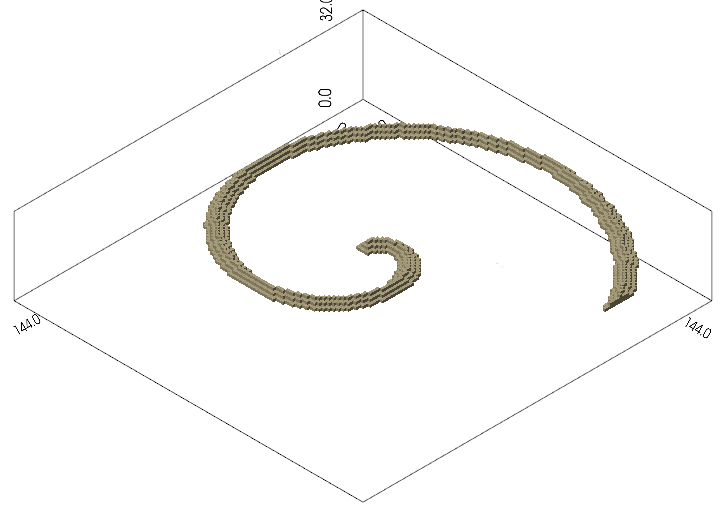

WindowsPath('seed_context_outputs/raised.png')

In [ ]:
grid_size = (5, 5)
voxels, known_mask = new_context_grid(grid_size, cell_size=32, overlap=4, height=32, fill_block="AIR")



draw_spiral(voxels, known_mask, block="SAND", axis="y", coord=18, center=(72, 72), start_radius=1.0, end_radius=80.0, turns=1.2, samples=300, width=4, add_air_above=True)
draw_spiral(voxels, known_mask, block="SAND", axis="y", coord=19, center=(72, 72), start_radius=1.0, end_radius=80.0, turns=1.2, samples=300, width=2, add_air_above=True)
draw_spiral(voxels, known_mask, block="SAND", axis="y", coord=20, center=(72, 72), start_radius=1.0, end_radius=80.0, turns=1.2, samples=300, width=1, add_air_above=True)


preview_context(voxels, known_mask, output_name="raised.png", textured=True, image_size=512, show_axis=True)

In [167]:
export_info = export_context_grid_layout(
    voxels,
    known_mask,
    layout_prefix="raisedspiral_sand",
    overlap=4,
    render_previews=False,
)

Saved seed context to seed_context_outputs\raisedspiral_sand_h00_d00.pt
Saved seed context to seed_context_outputs\raisedspiral_sand_h00_d01.pt
Saved seed context to seed_context_outputs\raisedspiral_sand_h00_d02.pt
Saved seed context to seed_context_outputs\raisedspiral_sand_h00_d03.pt
Saved seed context to seed_context_outputs\raisedspiral_sand_h00_d04.pt
Saved seed context to seed_context_outputs\raisedspiral_sand_h01_d00.pt
Saved seed context to seed_context_outputs\raisedspiral_sand_h01_d01.pt
Saved seed context to seed_context_outputs\raisedspiral_sand_h01_d02.pt
Saved seed context to seed_context_outputs\raisedspiral_sand_h01_d03.pt
Saved seed context to seed_context_outputs\raisedspiral_sand_h01_d04.pt
Saved seed context to seed_context_outputs\raisedspiral_sand_h02_d00.pt
Saved seed context to seed_context_outputs\raisedspiral_sand_h02_d01.pt
Saved seed context to seed_context_outputs\raisedspiral_sand_h02_d02.pt
Saved seed context to seed_context_outputs\raisedspiral_sand_h02

## Sine

Known voxels: 8502
Textured preview: True
Fitted camera: True
seed_context_outputs\waves.png


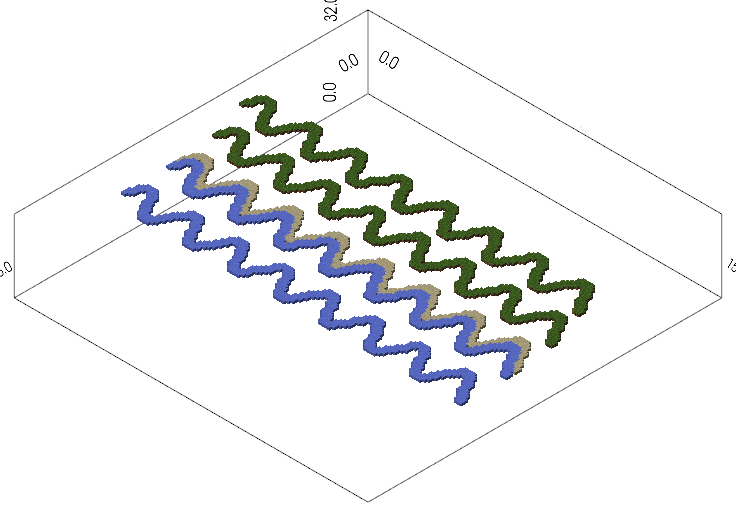

WindowsPath('seed_context_outputs/waves.png')

In [ ]:
grid_size = (5, 5)
voxels, known_mask = new_context_grid(grid_size, cell_size=32, overlap=1, height=32, fill_block="AIR")



wave(voxels, known_mask, block="SAND", y=16, travel_axis='z', travel_bounds=(0, 160), center=72, amplitude=6.0, wavelength=20.0, width=3, add_air_above=True)
wave(voxels, known_mask, block="WATER", y=16, travel_axis='z', travel_bounds=(0, 160), center=68, amplitude=6.0, wavelength=20.0, width=3, add_air_above=True)
wave(voxels, known_mask, block="WATER", y=16, travel_axis='z', travel_bounds=(0, 160), center=48, amplitude=6.0, wavelength=20.0, width=3, add_air_above=True)
wave(voxels, known_mask, block="GRASS", y=18, travel_axis='z', travel_bounds=(0, 160), center=88, amplitude=6.0, wavelength=20.0, width=3, add_air_above=True)

wave(voxels, known_mask, block="GRASS", y=24, travel_axis='z', travel_bounds=(0, 160), center=100, amplitude=6.0, wavelength=20.0, width=3, add_air_above=True)



preview_context(voxels, known_mask, output_name="waves.png", textured=True, image_size=512, show_axis=True)


In [180]:
export_info = export_context_grid_layout(
    voxels,
    known_mask,
    layout_prefix="morewaves_ol1",
    overlap=1,
    render_previews=False,
)

Saved seed context to seed_context_outputs\morewaves_ol1_h00_d00.pt
Saved seed context to seed_context_outputs\morewaves_ol1_h00_d01.pt
Saved seed context to seed_context_outputs\morewaves_ol1_h00_d02.pt
Saved seed context to seed_context_outputs\morewaves_ol1_h00_d03.pt
Saved seed context to seed_context_outputs\morewaves_ol1_h00_d04.pt
Saved seed context to seed_context_outputs\morewaves_ol1_h01_d00.pt
Saved seed context to seed_context_outputs\morewaves_ol1_h01_d01.pt
Saved seed context to seed_context_outputs\morewaves_ol1_h01_d02.pt
Saved seed context to seed_context_outputs\morewaves_ol1_h01_d03.pt
Saved seed context to seed_context_outputs\morewaves_ol1_h01_d04.pt
Saved seed context to seed_context_outputs\morewaves_ol1_h02_d00.pt
Saved seed context to seed_context_outputs\morewaves_ol1_h02_d01.pt
Saved seed context to seed_context_outputs\morewaves_ol1_h02_d02.pt
Saved seed context to seed_context_outputs\morewaves_ol1_h02_d03.pt
Saved seed context to seed_context_outputs\morew

## Circle river

c:\Users\TimBits\miniconda3\envs\py39\lib\site-packages\pyvista\core\dataset.py:604: PyVistaDeprecationWarning: Use of `DataSet.active_t_coords` is deprecated. Use `DataSet.active_texture_coordinates` instead.
  warnings.warn(


Known voxels: 8126
Textured preview: True
Fitted camera: True
seed_context_outputs\waves.png


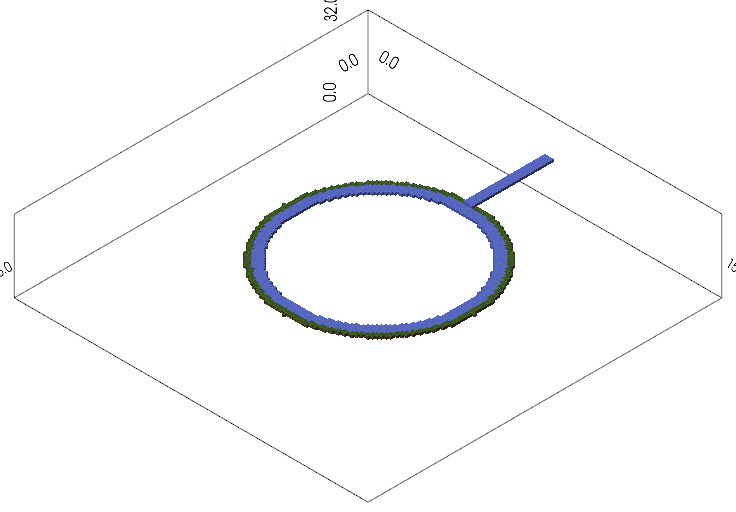

WindowsPath('seed_context_outputs/waves.png')

In [ ]:
grid_size = (5, 5)
voxels, known_mask = new_context_grid(grid_size, cell_size=32, overlap=1, height=32, fill_block="AIR")



draw_circle(voxels, known_mask, block="WATER", axis="y", coord=16, center=(80, 80), radius=38, thickness=4, add_air_above=True)
draw_circle(voxels, known_mask, block="GRASS", axis="y", coord=15, center=(80, 80), radius=41, thickness=2, add_air_above=True)

draw_plane(voxels, known_mask, block="WATER", axis="y", coord=15, u_bounds=(120, 160), v_bounds=(78, 82), thickness=1, add_air_above=True)



preview_context(voxels, known_mask, output_name="waves.png", textured=True, image_size=512, show_axis=True)


c:\Users\TimBits\miniconda3\envs\py39\lib\site-packages\pyvista\core\dataset.py:604: PyVistaDeprecationWarning: Use of `DataSet.active_t_coords` is deprecated. Use `DataSet.active_texture_coordinates` instead.
  warnings.warn(


Known voxels: 6022
Textured preview: True
Fitted camera: True
seed_context_outputs\dreamcubed_stitched_notebook_check.png


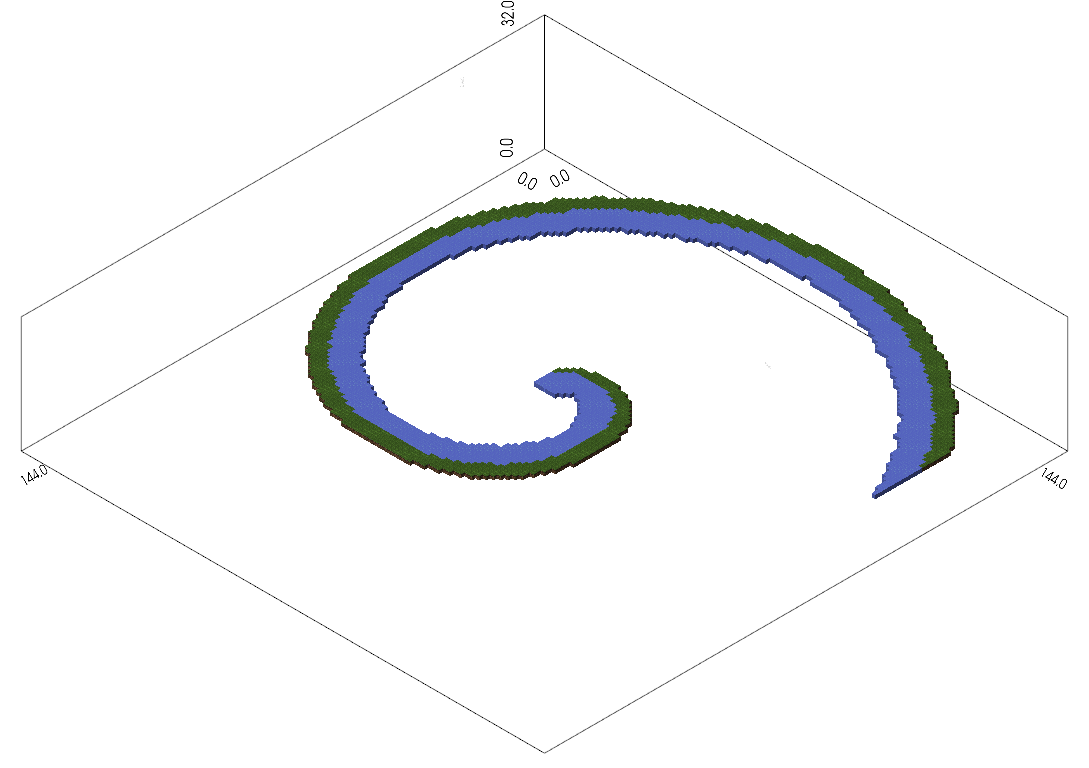

Stitched world shape: (144, 32, 144)
Seeded placements: 16
Seeded voxels: 7530


In [24]:
stitched_voxels, stitched_known_mask, meta = preview_stitched_seed_context(
    OUTPUT_DIR / "onespiral.json",
    output_name="dreamcubed_stitched_notebook_check.png",
    cell_size=32,
    overlap=4,
    vertical_overlap=4,
    textured=True,
    image_size=768,
    show_axis=True,
)

## Writing

Known voxels: 6674
Textured preview: True
Fitted camera: True
seed_context_outputs\dreamcubed.png


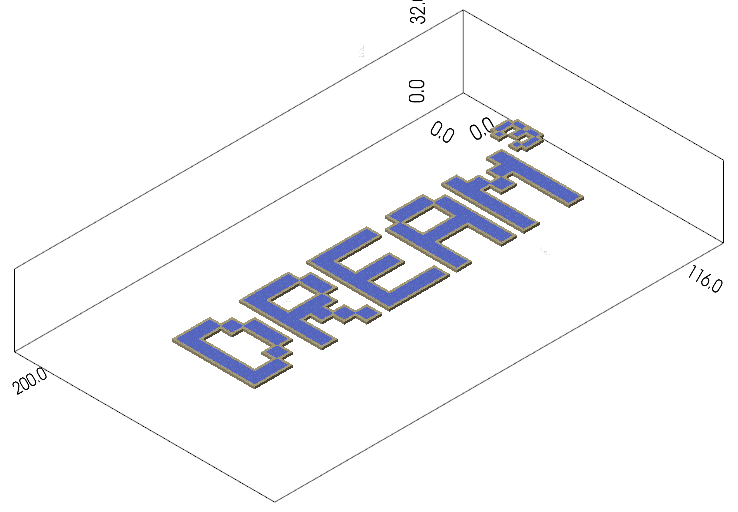

WindowsPath('seed_context_outputs/dreamcubed.png')

In [174]:
grid_size = (7, 4)
voxels, known_mask = new_context_grid(grid_size, cell_size=32, overlap=4, height=32, fill_block="AIR")




draw_text(voxels, known_mask, "DREAM", "WATER", origin=(24, 16, 48), scale=5, letter_spacing=5, filled=True, border_block="SAND", air_above_placed_only=True)
draw_text(voxels, known_mask, "3", "WATER", origin=(174, 16, 38), scale=2, letter_spacing=5, filled=True, border_block="SAND", air_above_placed_only=True)



preview_context(voxels, known_mask, output_name="dreamcubed.png", textured=True, image_size=512, show_axis=True)

In [175]:
export_info = export_context_grid_layout(
    voxels,
    known_mask,
    layout_prefix="dreamcubed_big_sand",
    overlap=4,
    render_previews=False,
)

Saved seed context to seed_context_outputs\dreamcubed_big_sand_h00_d00.pt
Saved seed context to seed_context_outputs\dreamcubed_big_sand_h00_d01.pt
Saved seed context to seed_context_outputs\dreamcubed_big_sand_h00_d02.pt
Saved seed context to seed_context_outputs\dreamcubed_big_sand_h00_d03.pt
Saved seed context to seed_context_outputs\dreamcubed_big_sand_h01_d00.pt
Saved seed context to seed_context_outputs\dreamcubed_big_sand_h01_d01.pt
Saved seed context to seed_context_outputs\dreamcubed_big_sand_h01_d02.pt
Saved seed context to seed_context_outputs\dreamcubed_big_sand_h01_d03.pt
Saved seed context to seed_context_outputs\dreamcubed_big_sand_h02_d00.pt
Saved seed context to seed_context_outputs\dreamcubed_big_sand_h02_d01.pt
Saved seed context to seed_context_outputs\dreamcubed_big_sand_h02_d02.pt
Saved seed context to seed_context_outputs\dreamcubed_big_sand_h02_d03.pt
Saved seed context to seed_context_outputs\dreamcubed_big_sand_h03_d00.pt
Saved seed context to seed_context_out

Known voxels: 6674
Textured preview: True
Fitted camera: True
seed_context_outputs\dreamcubed_stitched_notebook_check.png


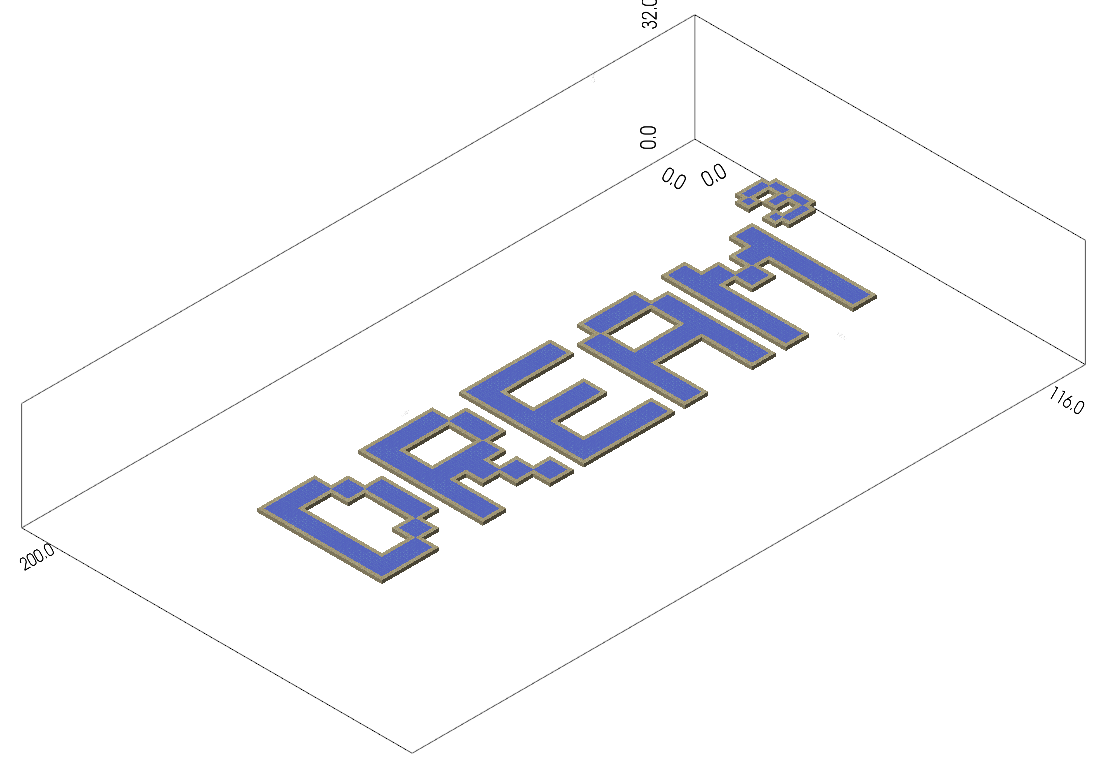

Stitched world shape: (200, 32, 116)
Seeded placements: 14
Seeded voxels: 8622


In [176]:
stitched_voxels, stitched_known_mask, meta = preview_stitched_seed_context(
    OUTPUT_DIR / "dreamcubed_big_sand.json",
    output_name="dreamcubed_stitched_notebook_check.png",
    cell_size=32,
    overlap=4,
    vertical_overlap=4,
    textured=True,
    image_size=768,
    show_axis=True,
)

torch.Size([172, 32, 116])
Known voxels: 7136
Textured preview: True
Fitted camera: True
seed_context_outputs\dreamcubed.png


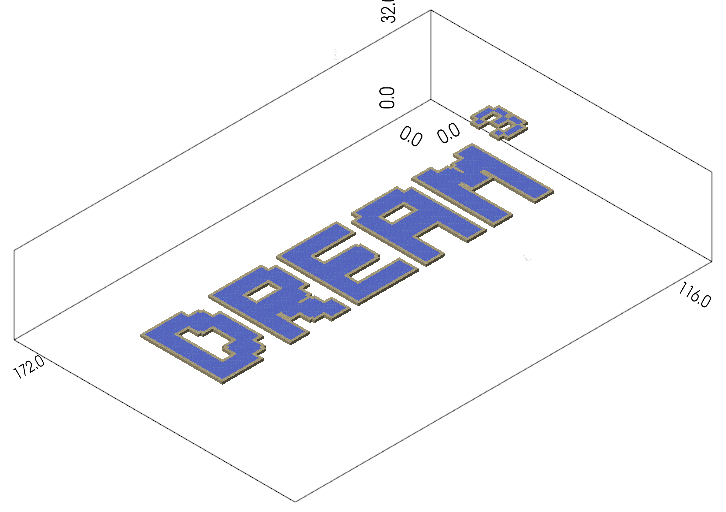

WindowsPath('seed_context_outputs/dreamcubed.png')

In [ ]:
grid_size = (6, 4)
voxels, known_mask = new_context_grid(grid_size, cell_size=32, overlap=4, height=32, fill_block="AIR")
print(voxels.shape)



draw_smooth_text(voxels, known_mask, "DREAM", "WATER", origin=(12, 16, 42), letter_spacing=5, filled=True, border_block="SAND", air_above_placed_only=True)
draw_text(voxels, known_mask, "3", "WATER", origin=(156, 16, 32), scale=2, letter_spacing=5, filled=True, border_block="SAND", air_above_placed_only=True)



preview_context(voxels, known_mask, output_name="dreamcubed.png", textured=True, image_size=512, show_axis=True)

In [233]:
export_info = export_context_grid_layout(
    voxels,
    known_mask,
    layout_prefix="dreamcubed_bigfont_sand",
    overlap=4,
    render_previews=False,
)

Saved seed context to seed_context_outputs\dreamcubed_bigfont_sand_h00_d00.pt
Saved seed context to seed_context_outputs\dreamcubed_bigfont_sand_h00_d01.pt
Saved seed context to seed_context_outputs\dreamcubed_bigfont_sand_h00_d02.pt
Saved seed context to seed_context_outputs\dreamcubed_bigfont_sand_h00_d03.pt
Saved seed context to seed_context_outputs\dreamcubed_bigfont_sand_h01_d00.pt
Saved seed context to seed_context_outputs\dreamcubed_bigfont_sand_h01_d01.pt
Saved seed context to seed_context_outputs\dreamcubed_bigfont_sand_h01_d02.pt
Saved seed context to seed_context_outputs\dreamcubed_bigfont_sand_h01_d03.pt
Saved seed context to seed_context_outputs\dreamcubed_bigfont_sand_h02_d00.pt
Saved seed context to seed_context_outputs\dreamcubed_bigfont_sand_h02_d01.pt
Saved seed context to seed_context_outputs\dreamcubed_bigfont_sand_h02_d02.pt
Saved seed context to seed_context_outputs\dreamcubed_bigfont_sand_h02_d03.pt
Saved seed context to seed_context_outputs\dreamcubed_bigfont_sa

In [251]:
grid_size = (3, 3)
voxels, known_mask = new_context_grid(grid_size, cell_size=32, overlap=4, height=32, fill_block="AIR")
voxels.shape

torch.Size([88, 32, 88])

In [252]:
grid_size = (5, 5)
voxels, known_mask = new_context_grid(grid_size, cell_size=32, overlap=4, height=32, fill_block="AIR")
voxels.shape

torch.Size([144, 32, 144])

c:\Users\TimBits\miniconda3\envs\py39\lib\site-packages\pyvista\core\dataset.py:604: PyVistaDeprecationWarning: Use of `DataSet.active_t_coords` is deprecated. Use `DataSet.active_texture_coordinates` instead.
  warnings.warn(


Known voxels: 7792
Textured preview: True
Fitted camera: True
seed_context_outputs\dreamcubed.png


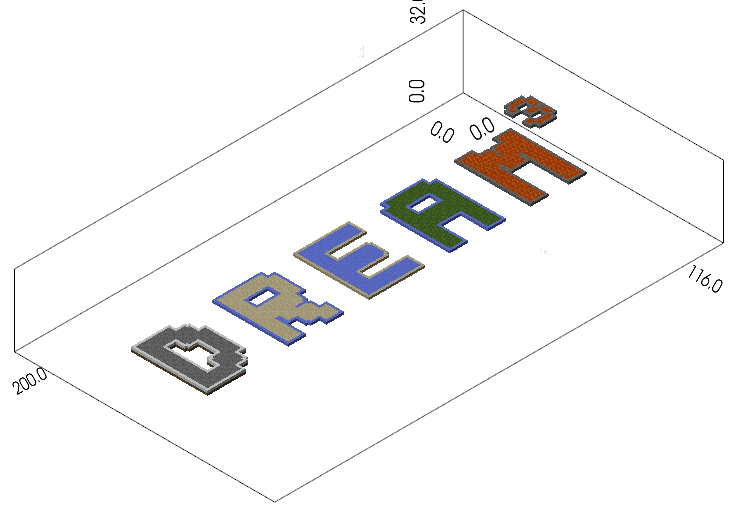

WindowsPath('seed_context_outputs/dreamcubed.png')

In [ ]:
grid_size = (7, 4)
voxels, known_mask = new_context_grid(grid_size, cell_size=32, overlap=4, height=32, fill_block="AIR")




draw_smooth_text(voxels, known_mask, "D", "STONE", origin=(12, 16, 42), letter_spacing=5, filled=True, border_block="SNOW", air_above_placed_only=True)
draw_smooth_text(voxels, known_mask, "D", "DIRT", origin=(12, 15, 42), letter_spacing=5, filled=True, border_block="GRASS")

draw_smooth_text(voxels, known_mask, "R", "SAND", origin=(48, 16, 42), letter_spacing=5, filled=True, border_block="WATER", air_above_placed_only=True)
draw_smooth_text(voxels, known_mask, "E", "WATER", origin=(84, 16, 42), letter_spacing=5, filled=True, border_block="SAND", air_above_placed_only=True)
draw_smooth_text(voxels, known_mask, "A", "GRASS", origin=(120, 16, 42), letter_spacing=5, filled=True, border_block="WATER", air_above_placed_only=True)
draw_smooth_text(voxels, known_mask, "M", "LAVA", origin=(156, 16, 42), letter_spacing=5, filled=True, border_block="STONE", air_above_placed_only=True)
draw_text(voxels, known_mask, "3", "LAVA", origin=(186, 16, 32), scale=2, letter_spacing=5, filled=True, border_block="STONE", air_above_placed_only=True)

preview_context(voxels, known_mask, output_name="dreamcubed.png", textured=True, image_size=512, show_axis=True)

c:\Users\TimBits\miniconda3\envs\py39\lib\site-packages\pyvista\core\dataset.py:604: PyVistaDeprecationWarning: Use of `DataSet.active_t_coords` is deprecated. Use `DataSet.active_texture_coordinates` instead.
  warnings.warn(


Known voxels: 8476
Textured preview: True
Fitted camera: True
seed_context_outputs\dreamcubed.png


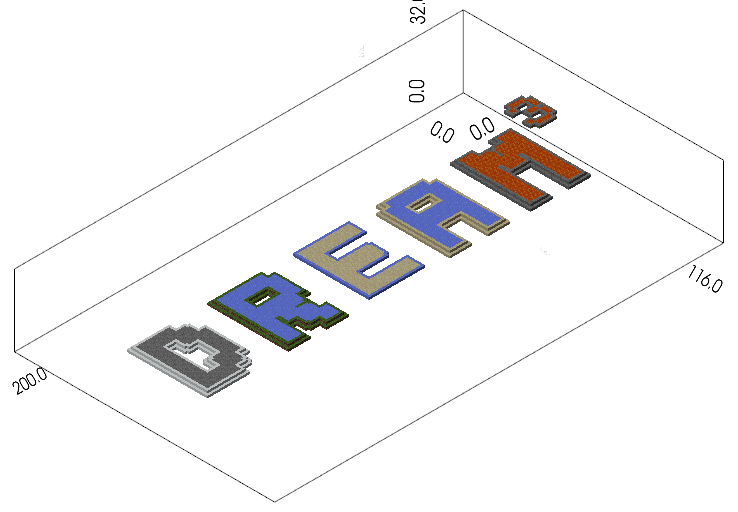

WindowsPath('seed_context_outputs/dreamcubed.png')

In [ ]:
grid_size = (7, 4)
voxels, known_mask = new_context_grid(grid_size, cell_size=32, overlap=4, height=32, fill_block="AIR")




draw_terraced_smooth_text(voxels, known_mask, "D", "STONE", origin=(12, 16, 42), letter_spacing=5, filled=True, border_block="SNOW", terrace_depth=1, air_above_placed_only=True)

draw_terraced_smooth_text(voxels, known_mask, "R", "WATER", origin=(48, 16, 42), letter_spacing=5, filled=True, border_block="GRASS", terrace_depth=1, air_above_placed_only=True)
draw_smooth_text(voxels, known_mask, "E", "SAND", origin=(84, 16, 42), letter_spacing=5, filled=True, border_block="WATER", air_above_placed_only=True)
draw_terraced_smooth_text(voxels, known_mask, "A", "WATER", origin=(120, 16, 42), letter_spacing=5, filled=True, border_block="SAND", terrace_depth=1, air_above_placed_only=True)
draw_terraced_smooth_text(voxels, known_mask, "M", "LAVA", origin=(156, 16, 42), letter_spacing=5, filled=True, border_block="STONE", terrace_depth=1, air_above_placed_only=True)
draw_text(voxels, known_mask, "3", "LAVA", origin=(186, 16, 32), scale=2, letter_spacing=5, filled=True, border_block="STONE", air_above_placed_only=True)


preview_context(voxels, known_mask, output_name="dreamcubed.png", textured=True, image_size=512, show_axis=True)

In [21]:
export_info = export_context_grid_layout(
    voxels,
    known_mask,
    layout_prefix="logo_terraced",
    overlap=4,
    render_previews=False,
)

Saved seed context to seed_context_outputs\logo_terraced_h00_d00.pt
Saved seed context to seed_context_outputs\logo_terraced_h00_d01.pt
Saved seed context to seed_context_outputs\logo_terraced_h00_d02.pt
Saved seed context to seed_context_outputs\logo_terraced_h00_d03.pt
Saved seed context to seed_context_outputs\logo_terraced_h01_d00.pt
Saved seed context to seed_context_outputs\logo_terraced_h01_d01.pt
Saved seed context to seed_context_outputs\logo_terraced_h01_d02.pt
Saved seed context to seed_context_outputs\logo_terraced_h01_d03.pt
Saved seed context to seed_context_outputs\logo_terraced_h02_d00.pt
Saved seed context to seed_context_outputs\logo_terraced_h02_d01.pt
Saved seed context to seed_context_outputs\logo_terraced_h02_d02.pt
Saved seed context to seed_context_outputs\logo_terraced_h02_d03.pt
Saved seed context to seed_context_outputs\logo_terraced_h03_d00.pt
Saved seed context to seed_context_outputs\logo_terraced_h03_d01.pt
Saved seed context to seed_context_outputs\logo_

Known voxels: 10580
Textured preview: True
Fitted camera: True
seed_context_outputs\dreamcubed.png


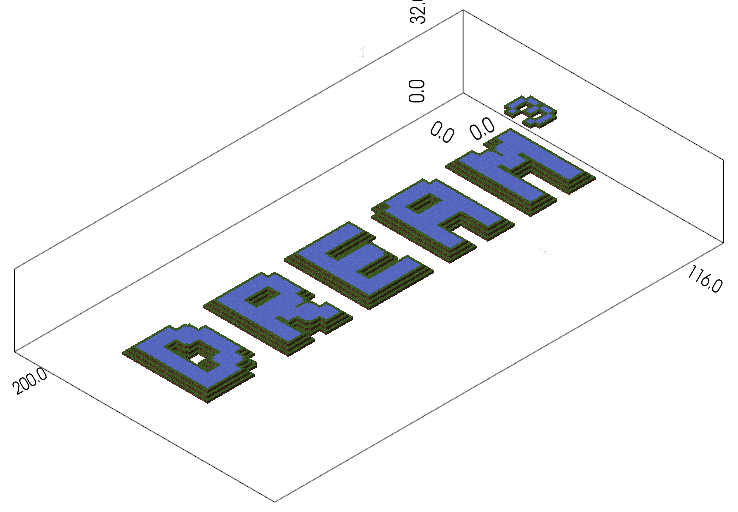

WindowsPath('seed_context_outputs/dreamcubed.png')

In [23]:
grid_size = (7, 4)
voxels, known_mask = new_context_grid(grid_size, cell_size=32, overlap=4, height=32, fill_block="AIR")




draw_terraced_smooth_text(voxels, known_mask, "D", "WATER", origin=(12, 16, 42), letter_spacing=5, filled=True, border_block="GRASS", terrace_depth=2, air_above_placed_only=True)

draw_terraced_smooth_text(voxels, known_mask, "R", "WATER", origin=(48, 16, 42), letter_spacing=5, filled=True, border_block="GRASS", terrace_depth=2, air_above_placed_only=True)
draw_terraced_smooth_text(voxels, known_mask, "E", "WATER", origin=(84, 16, 42), letter_spacing=5, filled=True, border_block="GRASS", terrace_depth=2, air_above_placed_only=True)
draw_terraced_smooth_text(voxels, known_mask, "A", "WATER", origin=(120, 16, 42), letter_spacing=5, filled=True, border_block="GRASS", terrace_depth=2, air_above_placed_only=True)
draw_terraced_smooth_text(voxels, known_mask, "M", "WATER", origin=(156, 16, 42), letter_spacing=5, filled=True, border_block="GRASS", terrace_depth=2, air_above_placed_only=True)
draw_text(voxels, known_mask, "3", "WATER", origin=(186, 16, 32), scale=2, letter_spacing=5, filled=True, border_block="GRASS", air_above_placed_only=True)





preview_context(voxels, known_mask, output_name="dreamcubed.png", textured=True, image_size=512, show_axis=True)

In [24]:
export_info = export_context_grid_layout(
    voxels,
    known_mask,
    layout_prefix="water_logo_terraced",
    overlap=4,
    render_previews=False,
)

Saved seed context to seed_context_outputs\water_logo_terraced_h00_d00.pt
Saved seed context to seed_context_outputs\water_logo_terraced_h00_d01.pt
Saved seed context to seed_context_outputs\water_logo_terraced_h00_d02.pt
Saved seed context to seed_context_outputs\water_logo_terraced_h00_d03.pt
Saved seed context to seed_context_outputs\water_logo_terraced_h01_d00.pt
Saved seed context to seed_context_outputs\water_logo_terraced_h01_d01.pt
Saved seed context to seed_context_outputs\water_logo_terraced_h01_d02.pt
Saved seed context to seed_context_outputs\water_logo_terraced_h01_d03.pt
Saved seed context to seed_context_outputs\water_logo_terraced_h02_d00.pt
Saved seed context to seed_context_outputs\water_logo_terraced_h02_d01.pt
Saved seed context to seed_context_outputs\water_logo_terraced_h02_d02.pt
Saved seed context to seed_context_outputs\water_logo_terraced_h02_d03.pt
Saved seed context to seed_context_outputs\water_logo_terraced_h03_d00.pt
Saved seed context to seed_context_out

# Village Piece Slicer

Load a tensor of village samples, pick one, slice out a sub-region, save it as a reusable **piece**, and paste it into a new context.

Piece shape: (5, 15, 1)
Known voxels: 75
Textured preview: True
Fitted camera: True
seed_context_outputs\village_piece_preview.png


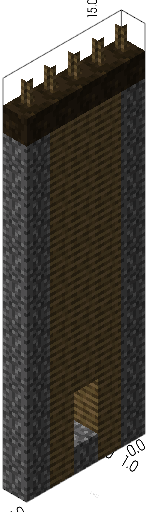

Saved piece (5, 15, 1) to seed_context_outputs\tower_front_01.pt


WindowsPath('seed_context_outputs/tower_front_01.pt')

In [ ]:
# ── Step 2: Slice & Save a Piece ─────────────────────────────────────────
# Specify the sub-region you want to extract.
# Ranges are [start, end) in each axis — standard Python slicing.

H_RANGE = (2, 7)   # horizontal slice
Y_RANGE = (11, 26)   # vertical slice (full height keeps the whole column)
D_RANGE = (8, 9)   # depth slice

piece = sampled_converted[H_RANGE[0]:H_RANGE[1], Y_RANGE[0]:Y_RANGE[1], D_RANGE[0]:D_RANGE[1]].clone()
print(f"Piece shape: {tuple(piece.shape)}")

piece_known = torch.ones_like(piece, dtype=torch.bool)
preview_context(piece, piece_known, output_name="village_piece_preview.png", textured=True, image_size=512)

PIECE_NAME = "tower_front_01"
save_piece(
    OUTPUT_DIR / f"{PIECE_NAME}.pt",
    piece,
    metadata={
        "source_file": str(VILLAGE_TENSOR_PATH),
        "source_sample_idx": SAMPLE_IDX,
        "source_slice_h": H_RANGE,
        "source_slice_y": Y_RANGE,
        "source_slice_d": D_RANGE,
    },
)